In [41]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


In [42]:
SCENARIOS = [
    "unified_example",
    "unified_example_full",
    "unified_example_full_with_subtraction",
    "unified_example_full_with_subtraction_100Hz",
    "unified_example_full_with_subtraction_500Hz_larger_larger",
    "Model_1",
]

MODEL_NAMES = [
    "angle_collected",
    "mass_collected",
    "mass_public",
    "angle_mass_collected",
]

MODEL_SPECS = {
    "angle_collected": {"scope": "angle", "datasets": ["collected"]},
    "mass_collected": {"scope": "mass", "datasets": ["collected"]},
    "mass_public": {"scope": "mass", "datasets": ["public"]},
    "angle_mass_collected": {"scope": "both", "datasets": ["collected"]},
}

MODEL_ROOT_BASE = Path.cwd() / "Models"
OUTPUT_DIR = MODEL_ROOT_BASE / "comparison_reports"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("MODEL_ROOT_BASE:", MODEL_ROOT_BASE)
print("SCENARIOS:", SCENARIOS)
print("OUTPUT_DIR:", OUTPUT_DIR)


MODEL_ROOT_BASE: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models
SCENARIOS: ['unified_example', 'unified_example_full', 'unified_example_full_with_subtraction', 'unified_example_full_with_subtraction_100Hz', 'unified_example_full_with_subtraction_500Hz_larger_larger', 'Model_1']
OUTPUT_DIR: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\comparison_reports


In [ ]:
def additional_data_dir(scenario_name, model_name):
    return MODEL_ROOT_BASE / scenario_name / "additional_data" / model_name


def read_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def normalize_metrics_payload(payload):
    """Support both old metrics.json format and expanded metrics.json format."""
    if not payload:
        return {}, [], {}

    final_metrics = payload.get("final_metrics") if isinstance(payload.get("final_metrics"), dict) else {}
    if not final_metrics:
        final_metrics = {
            k: v for k, v in payload.items()
            if isinstance(v, (int, float)) and k not in {"best_epoch"}
        }

    training_history = payload.get("training_history", payload.get("history", []))
    if isinstance(training_history, dict):
        training_history = list(training_history.values())
    if training_history is None:
        training_history = []

    run_config = payload.get("run_config", {}) if isinstance(payload.get("run_config", {}), dict) else {}
    return final_metrics, training_history, run_config


def load_history(scenario_name, model_name):
    folder = additional_data_dir(scenario_name, model_name)
    metrics_payload = read_json(folder / "metrics.json")
    _, history_records, _ = normalize_metrics_payload(metrics_payload)

    if history_records:
        history = pd.DataFrame(history_records)
    else:
        history_path = folder / "history.csv"
        if history_path.exists():
            history = pd.read_csv(history_path)
        else:
            return pd.DataFrame()

    if len(history) == 0:
        return history

    history = history.copy()
    history.insert(0, "scenario_name", scenario_name)
    history.insert(1, "model_name", model_name)
    for col in history.columns:
        if col not in {"scenario_name", "model_name"}:
            history[col] = pd.to_numeric(history[col], errors="coerce")
    return history


def load_main_metrics(scenario_name, model_name):
    folder = additional_data_dir(scenario_name, model_name)
    metrics_payload = read_json(folder / "metrics.json")
    final_metrics, _, run_config = normalize_metrics_payload(metrics_payload)

    rows = []
    for metric_name, metric_value in final_metrics.items():
        if isinstance(metric_value, (int, float, np.integer, np.floating)) and not pd.isna(metric_value):
            rows.append({
                "scenario_name": scenario_name,
                "model_name": model_name,
                "metric": metric_name,
                "value": float(metric_value),
                "source": "metrics_json_final",
            })

    final_grade_path = folder / "final_grade.csv"
    if final_grade_path.exists():
        grade = pd.read_csv(final_grade_path)
        for _, row in grade.iterrows():
            value = row.get("value", np.nan)
            if pd.notna(value):
                rows.append({
                    "scenario_name": scenario_name,
                    "model_name": model_name,
                    "metric": str(row.get("metric")),
                    "value": float(value),
                    "unit": str(row.get("unit", "")),
                    "source": "final_grade_csv",
                })

    result = pd.DataFrame(rows)
    if len(result) and "unit" not in result.columns:
        result["unit"] = ""
    return result


def load_model_bundle(model_name):
    histories = []
    metrics = []
    missing = []

    for scenario_name in SCENARIOS:
        folder = additional_data_dir(scenario_name, model_name)
        if not folder.exists():
            missing.append(str(folder))
            continue

        history = load_history(scenario_name, model_name)
        if len(history):
            histories.append(history)

        metric_df = load_main_metrics(scenario_name, model_name)
        if len(metric_df):
            metrics.append(metric_df)

    history_df = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    metrics_df = pd.concat(metrics, ignore_index=True) if metrics else pd.DataFrame()
    return history_df, metrics_df, missing


def available_runs_table():
    rows = []
    for scenario_name in SCENARIOS:
        for model_name in MODEL_NAMES:
            folder = additional_data_dir(scenario_name, model_name)
            rows.append({
                "scenario_name": scenario_name,
                "model_name": model_name,
                "folder_exists": folder.exists(),
                "metrics_json": (folder / "metrics.json").exists(),
                "history_csv": (folder / "history.csv").exists(),
                "final_grade_csv": (folder / "final_grade.csv").exists(),
            })
    return pd.DataFrame(rows)


In [ ]:
# =============================================================================
# PLOTTING HELPERS
# =============================================================================
def _plot_metric_lines(history_df, metric_columns, title, ylabel):
    metric_columns = [c for c in metric_columns if c in history_df.columns]
    if len(history_df) == 0 or not metric_columns:
        print(f"Skipping line plot: {title}. Missing columns: {metric_columns}")
        return

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=(11, 4.5))
        for scenario_name in SCENARIOS:
            scenario_df = history_df[history_df["scenario_name"] == scenario_name].copy()
            if len(scenario_df) == 0:
                continue
            scenario_df = scenario_df.sort_values("epoch")
            for metric_col in metric_columns:
                if scenario_df[metric_col].notna().any():
                    label = f"{scenario_name} | {metric_col}"
                    ax.plot(scenario_df["epoch"], scenario_df[metric_col], label=label)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()


def plot_training_history_comparison(model_name, history_df):
    if len(history_df) == 0:
        print(f"No training history found for {model_name}.")
        return

    _plot_metric_lines(
        history_df,
        metric_columns=["train_loss", "val_loss"],
        title=f"{model_name}: train/test loss history",
        ylabel="MSE loss",
    )

    if "val_angle_mae_deg" in history_df.columns:
        _plot_metric_lines(
            history_df,
            metric_columns=["val_angle_mae_deg"],
            title=f"{model_name}: validation angle MAE history",
            ylabel="Angle MAE [deg]",
        )

    if "val_mass_mae_relative" in history_df.columns:
        _plot_metric_lines(
            history_df,
            metric_columns=["val_mass_mae_relative"],
            title=f"{model_name}: validation mass MAE history",
            ylabel="Mass MAE [relative]",
        )


def infer_metric_unit(metric_name):
    if "angle" in metric_name and "deg" in metric_name:
        return "deg"
    if "mass" in metric_name and "relative" in metric_name:
        return "relative"
    if "gmm" in metric_name or "g*mm" in metric_name:
        return "g*mm"
    if "loss" in metric_name:
        return "MSE"
    return "value"


def main_metrics_for_bars(metrics_df, model_name):
    if len(metrics_df) == 0:
        return metrics_df

    preferred = [
        "loss",
        "angle_mae_deg",
        "mass_mae_relative",
        "test_loss_best_model",
        "test_angle_mae_from_evaluate",
        "test_mass_mae_from_evaluate",
        "angle_abs_error_mean",
        "mass_abs_error_mean",
    ]
    df = metrics_df[metrics_df["metric"].isin(preferred)].copy()
    if len(df) == 0:
        df = metrics_df[metrics_df["source"] == "metrics_json_final"].copy()

    if len(df) == 0:
        return df


    df["metric_order"] = df["metric"].apply(lambda x: preferred.index(x) if x in preferred else 999)
    df = df.sort_values(["metric_order", "source"]).drop_duplicates(["scenario_name", "metric"], keep="first")
    if "unit" not in df.columns:
        df["unit"] = ""
    df["unit"] = df.apply(
        lambda r: r["unit"] if isinstance(r.get("unit", ""), str) and r.get("unit", "") not in {"", "nan"} else infer_metric_unit(str(r["metric"])),
        axis=1,
    )
    return df.drop(columns=["metric_order"], errors="ignore")


def plot_main_metric_bars(model_name, metrics_df):
    df = main_metrics_for_bars(metrics_df, model_name)
    if len(df) == 0:
        print(f"No main metrics found for bar plots: {model_name}.")
        return

    for metric_name in df["metric"].drop_duplicates():
        metric_df = df[df["metric"] == metric_name].copy()
        metric_df = metric_df.set_index("scenario_name").reindex(SCENARIOS).reset_index()
        metric_df = metric_df.dropna(subset=["value"])
        if len(metric_df) == 0:
            continue
        unit = metric_df["unit"].dropna().iloc[0] if "unit" in metric_df.columns and metric_df["unit"].notna().any() else infer_metric_unit(metric_name)
        fig, ax = plt.subplots(figsize=(24, 6))
        ax.bar(metric_df["scenario_name"], metric_df["value"])
        ax.set_title(f"{model_name}: {metric_name}")
        ax.set_ylabel(str(unit))
        ax.set_xlabel("Scenario")
        ax.tick_params(axis="x", rotation=20)
        plt.tight_layout()
        plt.show()


def display_model_comparison(model_name):
    history_df, metrics_df, missing = load_model_bundle(model_name)
    display(Markdown(f"## {model_name}"))

    spec = MODEL_SPECS.get(model_name, {})
    if spec:
        display(pd.DataFrame([{**{"model_name": model_name}, **spec}]))

    if missing:
        print("Missing result folders:")
        for path in missing:
            print(" -", path)

    display(Markdown("### Training history plots"))
    plot_training_history_comparison(model_name, history_df)

    display(Markdown("### Main metrics table"))
    if len(metrics_df):
        main_df = main_metrics_for_bars(metrics_df, model_name)
        display(main_df.sort_values(["metric", "scenario_name"]))
        out_path = OUTPUT_DIR / f"{model_name}_main_metrics_comparison.csv"
        main_df.to_csv(out_path, index=False)
        print("Saved:", out_path)
    else:
        print(f"No metrics found for {model_name}.")

    display(Markdown("### Main metrics bar plots"))
    plot_main_metric_bars(model_name, metrics_df)

    if len(history_df):
        out_path = OUTPUT_DIR / f"{model_name}_history_comparison.csv"
        history_df.to_csv(out_path, index=False)
        print("Saved:", out_path)

    return history_df, metrics_df


## Available saved runs

In [45]:
runs = available_runs_table()
display(runs)
runs.to_csv(OUTPUT_DIR / "available_runs.csv", index=False)
print("Saved:", OUTPUT_DIR / "available_runs.csv")

,scenario_name,model_name,folder_exists,metrics_json,history_csv,final_grade_csv
0,unified_example,angle_collected,True,True,True,True
1,unified_example,mass_collected,True,True,True,True
2,unified_example,mass_public,True,True,True,True
3,unified_example,angle_mass_collected,True,True,True,True
4,unified_example_full,angle_collected,True,True,True,True
5,unified_example_full,mass_collected,True,True,True,True
6,unified_example_full,mass_public,True,True,True,True
7,unified_example_full,angle_mass_collected,True,True,True,True
8,unified_example_full_with_subtraction,angle_collected,True,True,True,True
9,unified_example_full_with_subtraction,mass_collected,True,True,True,True


Saved: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\comparison_reports\available_runs.csv


## Compare `angle_collected`

## angle_collected

,model_name,scope,datasets
0,angle_collected,angle,[collected]


### Training history plots

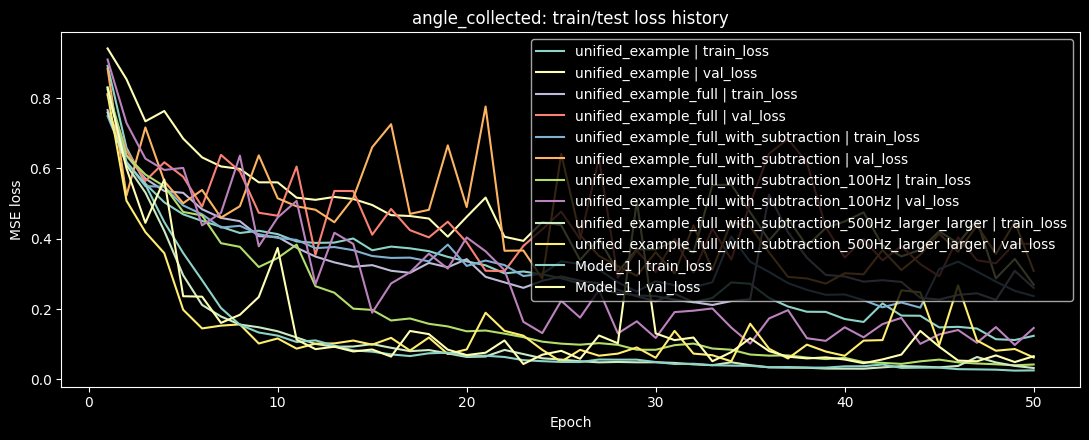

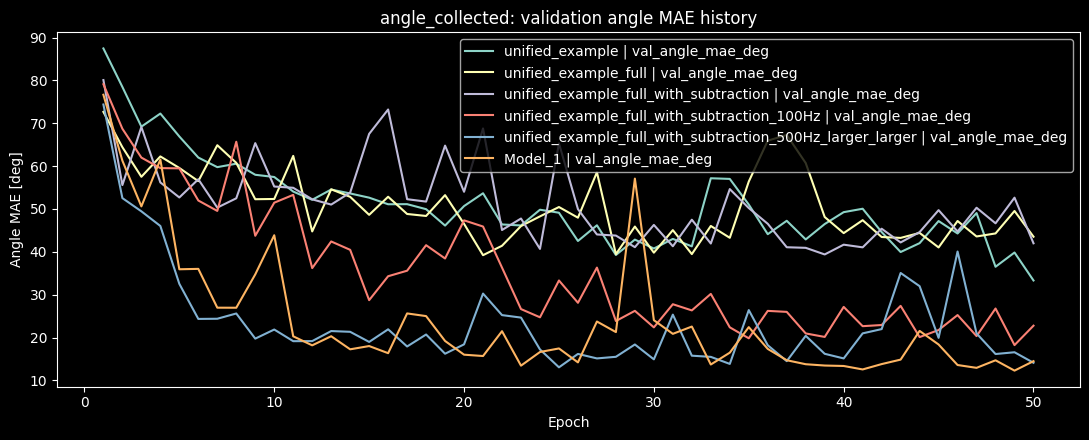

### Main metrics table

,scenario_name,model_name,metric,value,source,unit
44,Model_1,angle_collected,angle_abs_error_mean,13.458707,final_grade_csv,deg
4,unified_example,angle_collected,angle_abs_error_mean,33.327661,final_grade_csv,deg
12,unified_example_full,angle_collected,angle_abs_error_mean,39.470481,final_grade_csv,deg
20,unified_example_full_with_subtraction,angle_collected,angle_abs_error_mean,39.399349,final_grade_csv,deg
28,unified_example_full_with_subtraction_100Hz,angle_collected,angle_abs_error_mean,18.255166,final_grade_csv,deg
36,unified_example_full_with_subtraction_500Hz_la...,angle_collected,angle_abs_error_mean,13.070059,final_grade_csv,deg
41,Model_1,angle_collected,angle_mae_deg,13.458706,metrics_json_final,deg
1,unified_example,angle_collected,angle_mae_deg,33.327660,metrics_json_final,deg
9,unified_example_full,angle_collected,angle_mae_deg,39.470478,metrics_json_final,deg
17,unified_example_full_with_subtraction,angle_collected,angle_mae_deg,39.399345,metrics_json_final,deg


Saved: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\comparison_reports\angle_collected_main_metrics_comparison.csv


### Main metrics bar plots

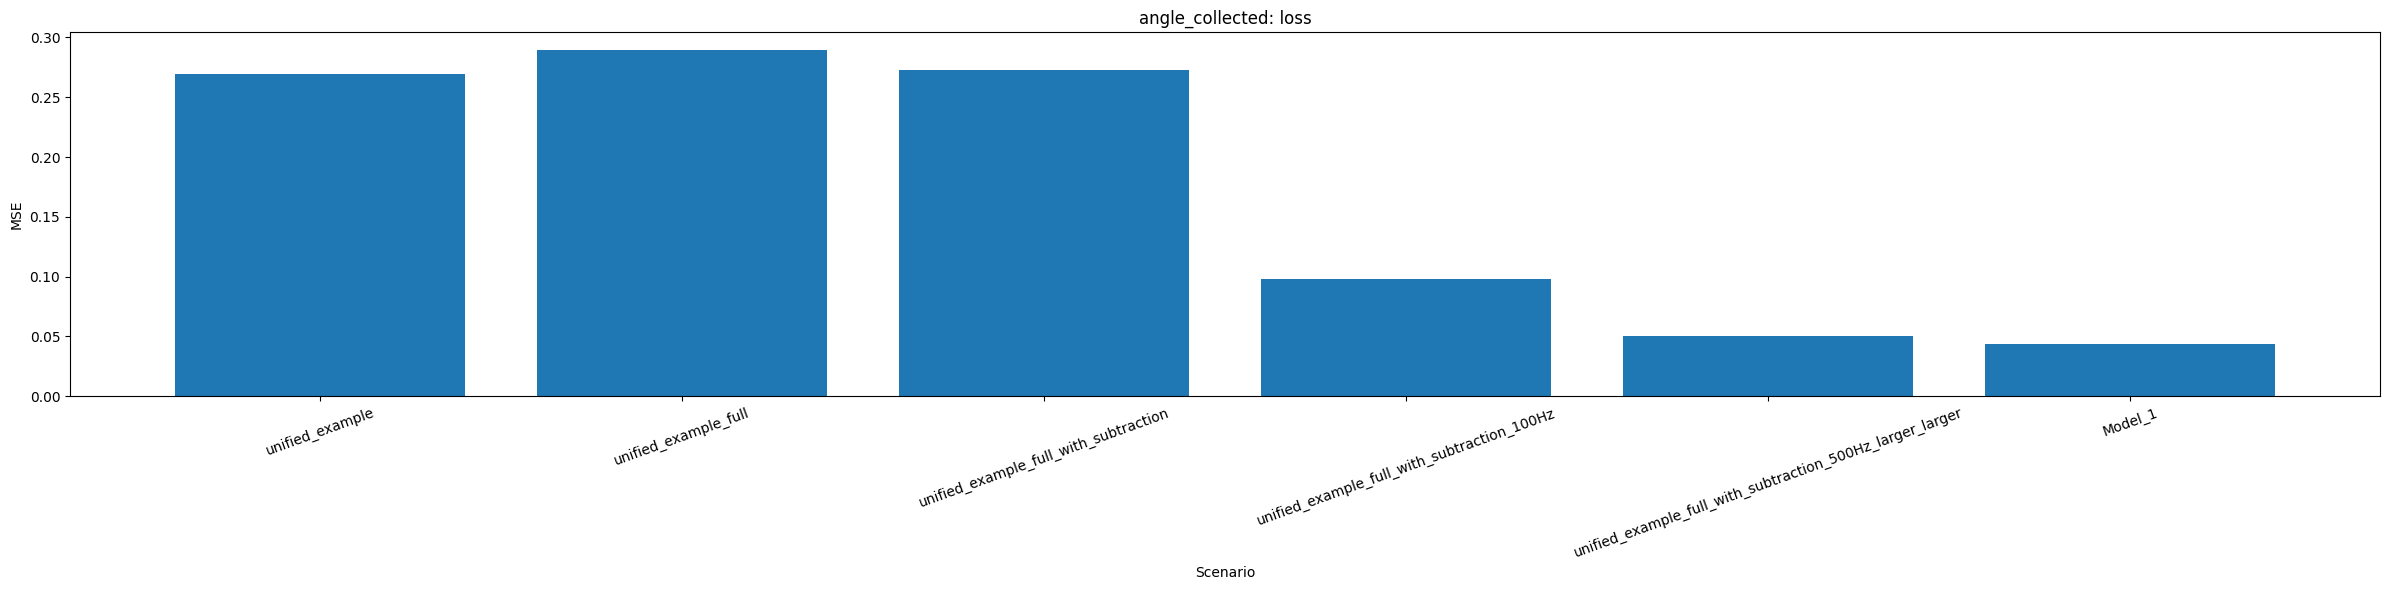

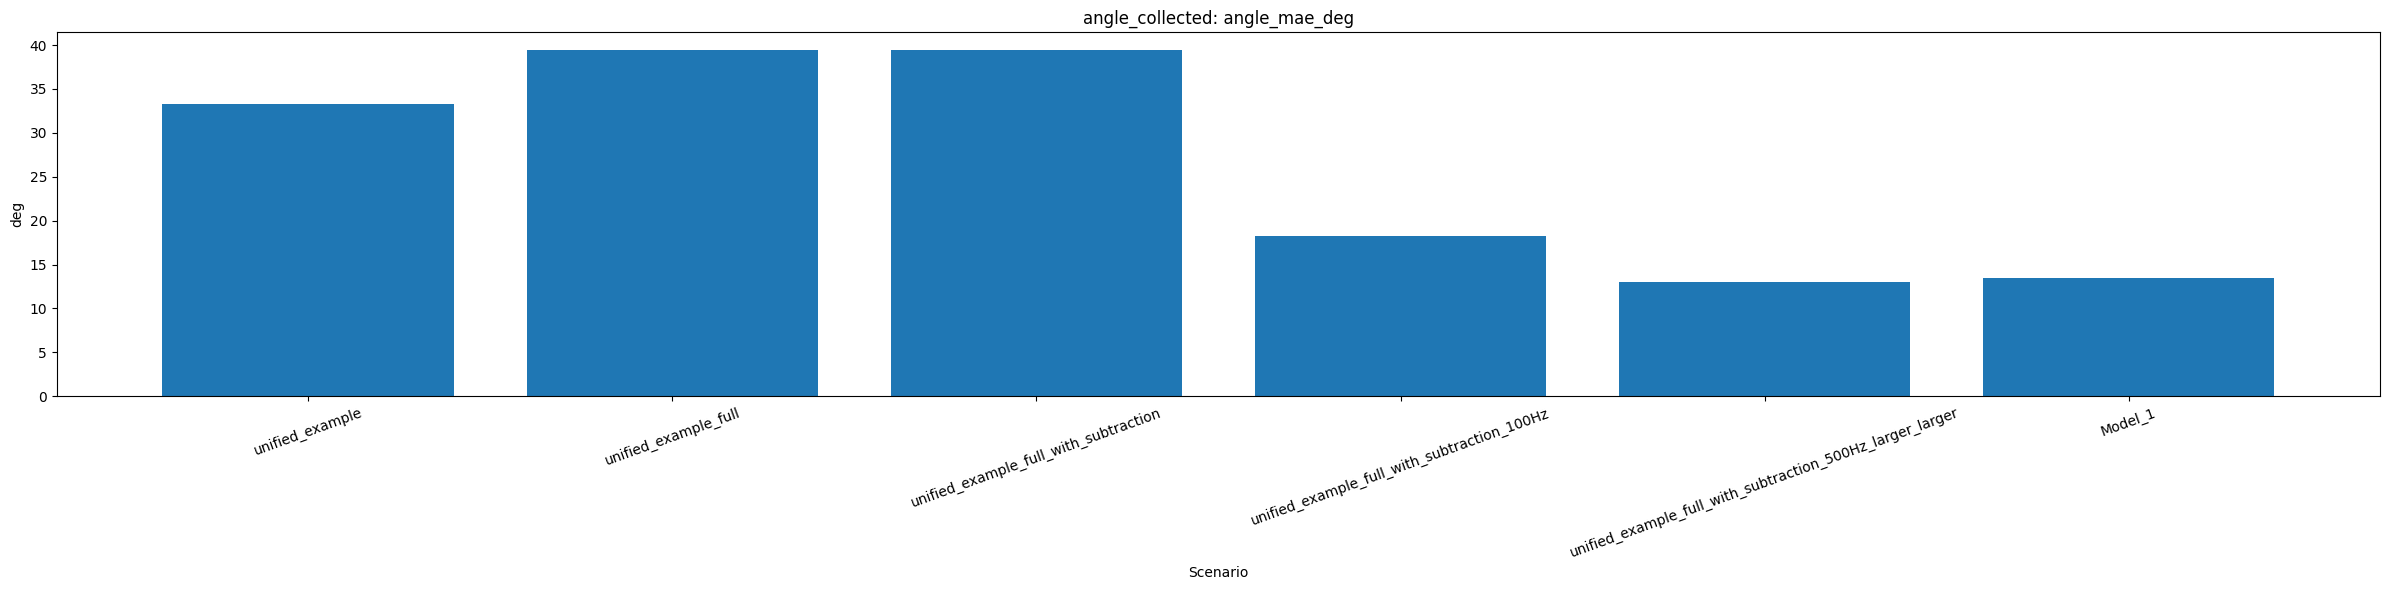

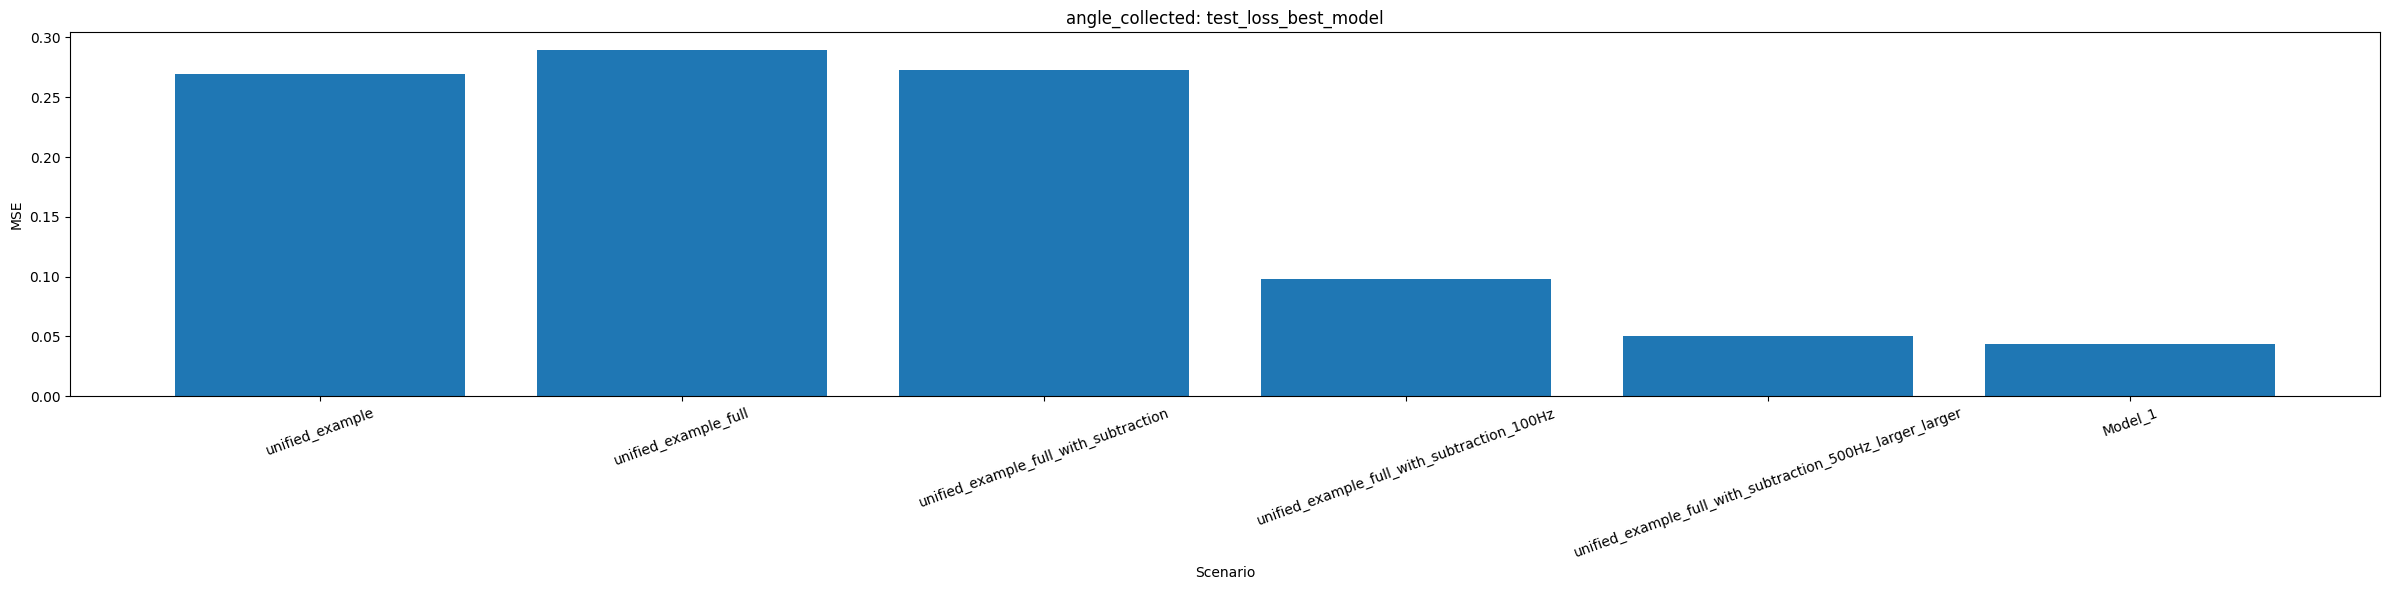

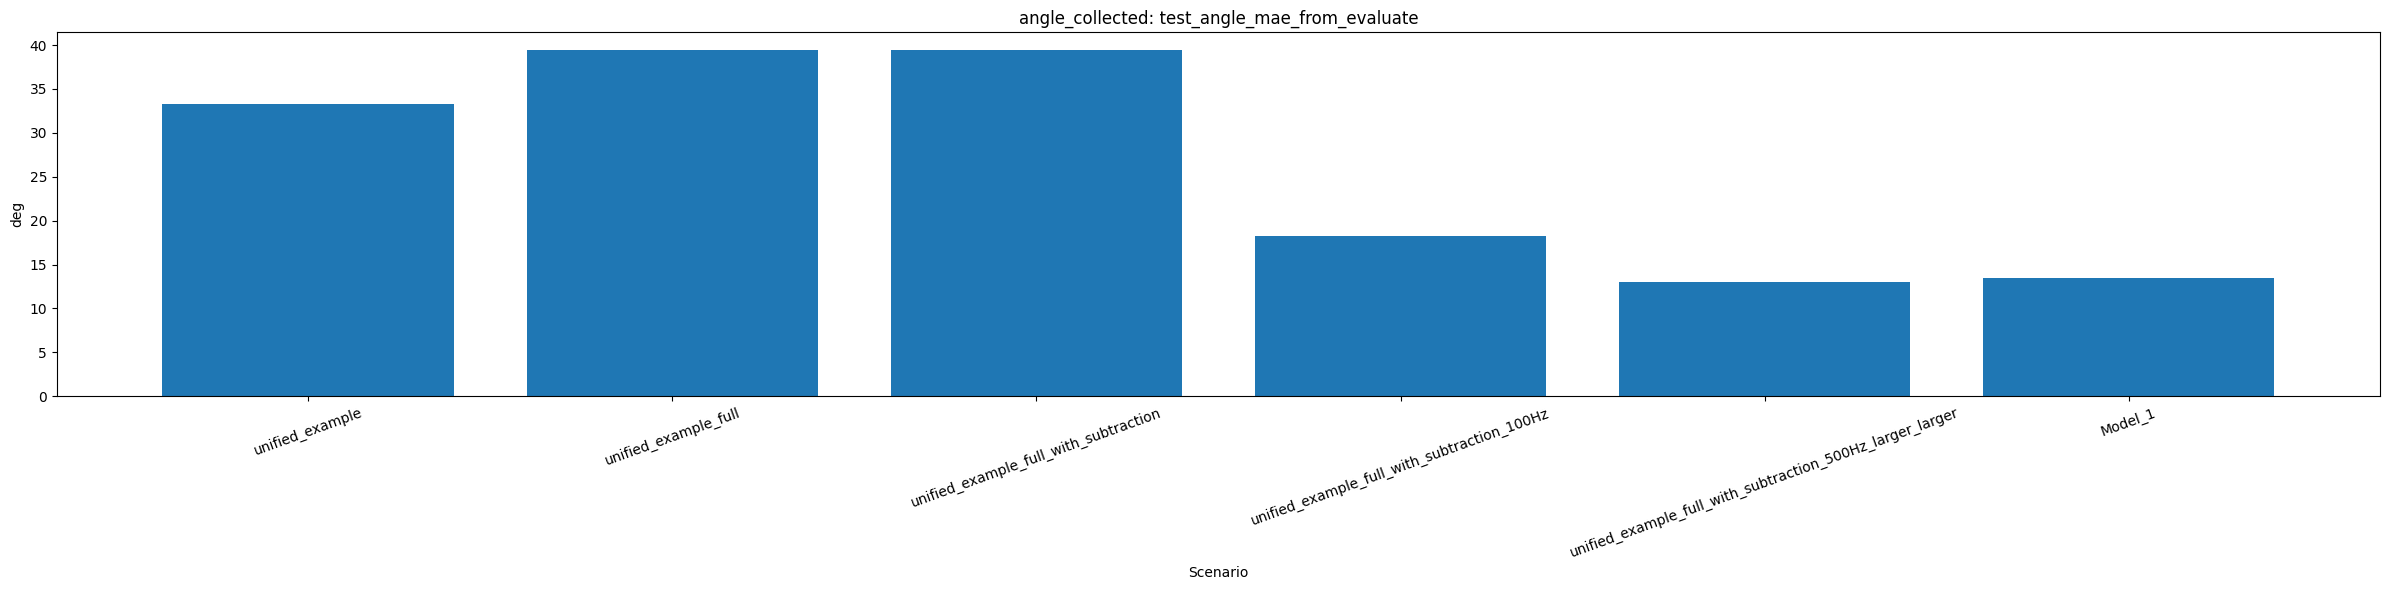

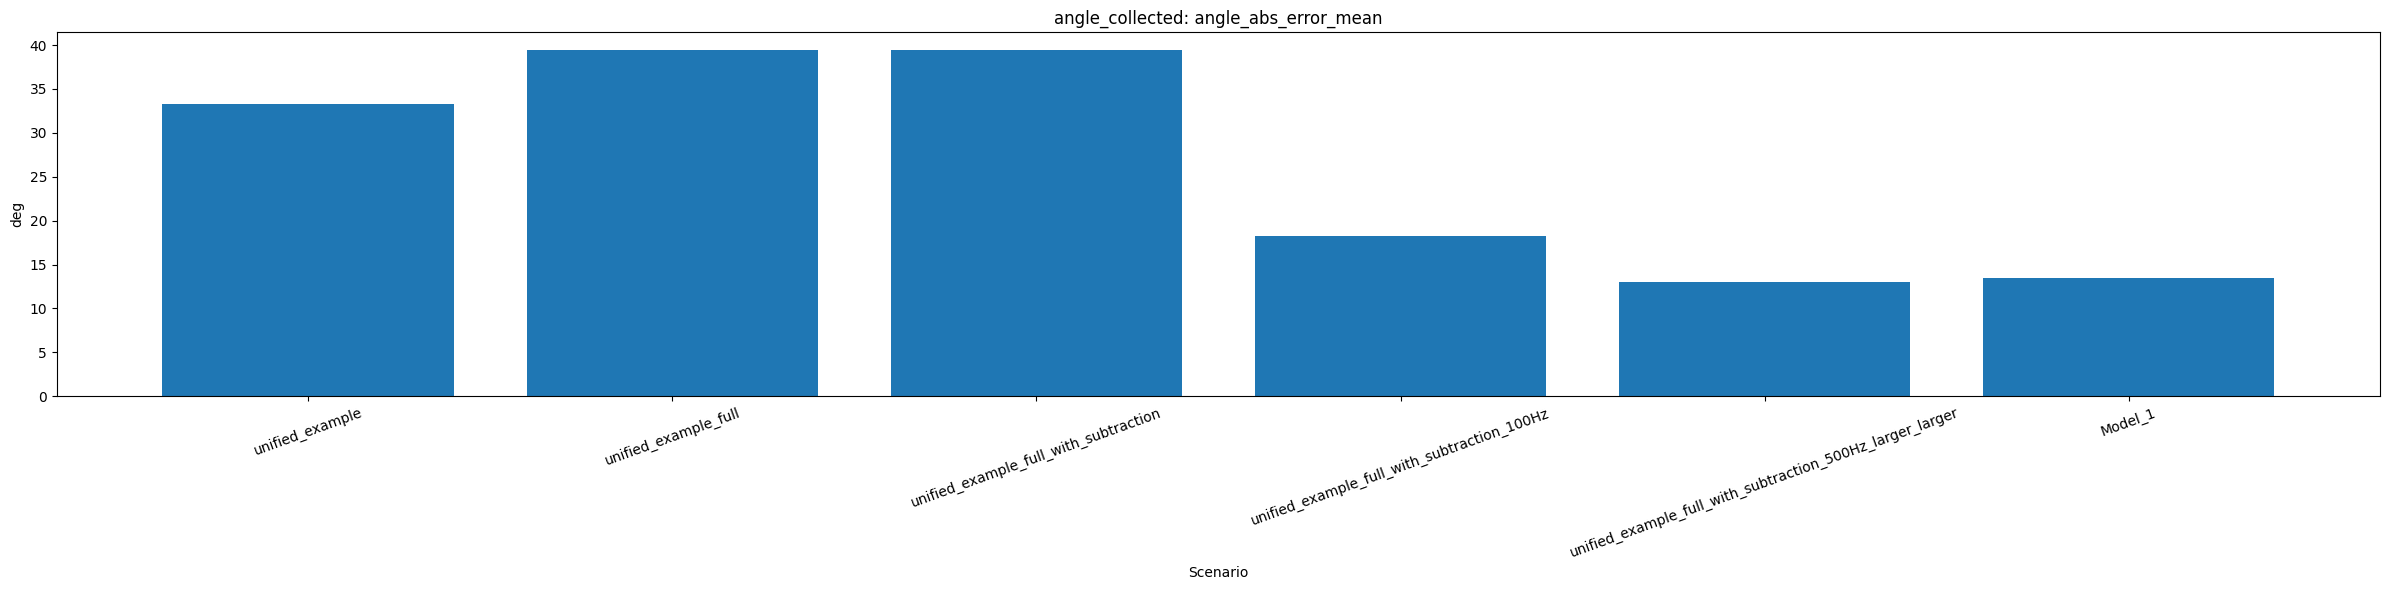

Saved: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\comparison_reports\angle_collected_history_comparison.csv


In [46]:
angle_collected_history_comparison, angle_collected_metrics_comparison = display_model_comparison("angle_collected")

## Compare `mass_collected`

## mass_collected

,model_name,scope,datasets
0,mass_collected,mass,[collected]


### Training history plots

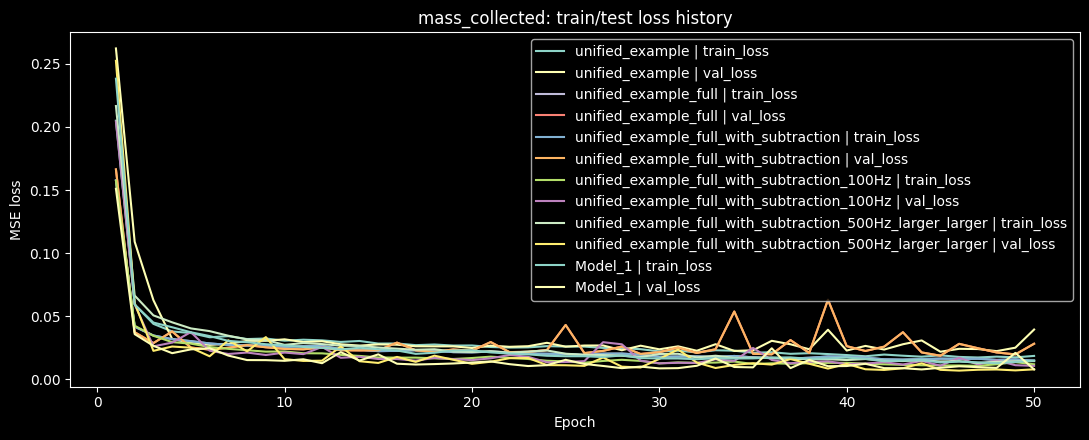

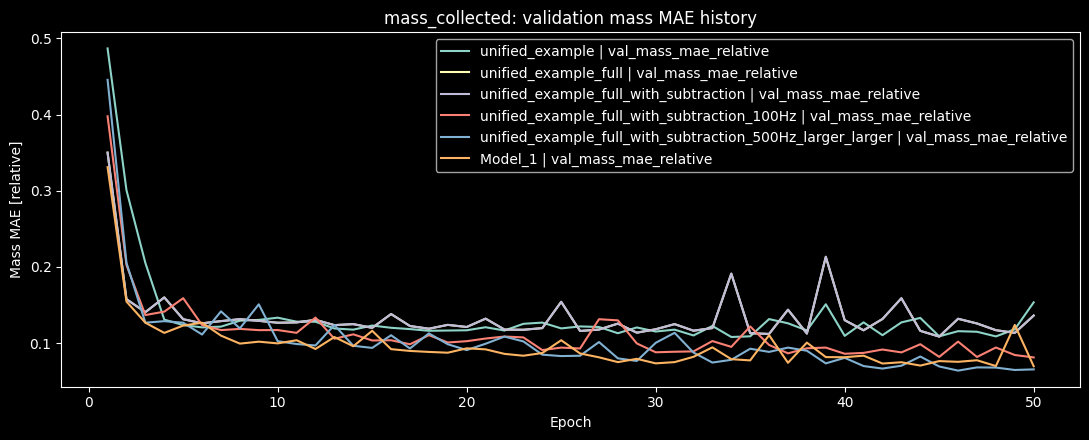

### Main metrics table

,scenario_name,model_name,metric,value,source,unit
60,Model_1,mass_collected,loss,0.007895,metrics_json_final,MSE
0,unified_example,mass_collected,loss,0.021912,metrics_json_final,MSE
12,unified_example_full,mass_collected,loss,0.018743,metrics_json_final,MSE
24,unified_example_full_with_subtraction,mass_collected,loss,0.018743,metrics_json_final,MSE
36,unified_example_full_with_subtraction_100Hz,mass_collected,loss,0.010704,metrics_json_final,MSE
48,unified_example_full_with_subtraction_500Hz_la...,mass_collected,loss,0.006952,metrics_json_final,MSE
64,Model_1,mass_collected,mass_abs_error_mean,0.070572,final_grade_csv,relative
4,unified_example,mass_collected,mass_abs_error_mean,0.108934,final_grade_csv,relative
16,unified_example_full,mass_collected,mass_abs_error_mean,0.108639,final_grade_csv,relative
28,unified_example_full_with_subtraction,mass_collected,mass_abs_error_mean,0.108639,final_grade_csv,relative


Saved: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\comparison_reports\mass_collected_main_metrics_comparison.csv


### Main metrics bar plots

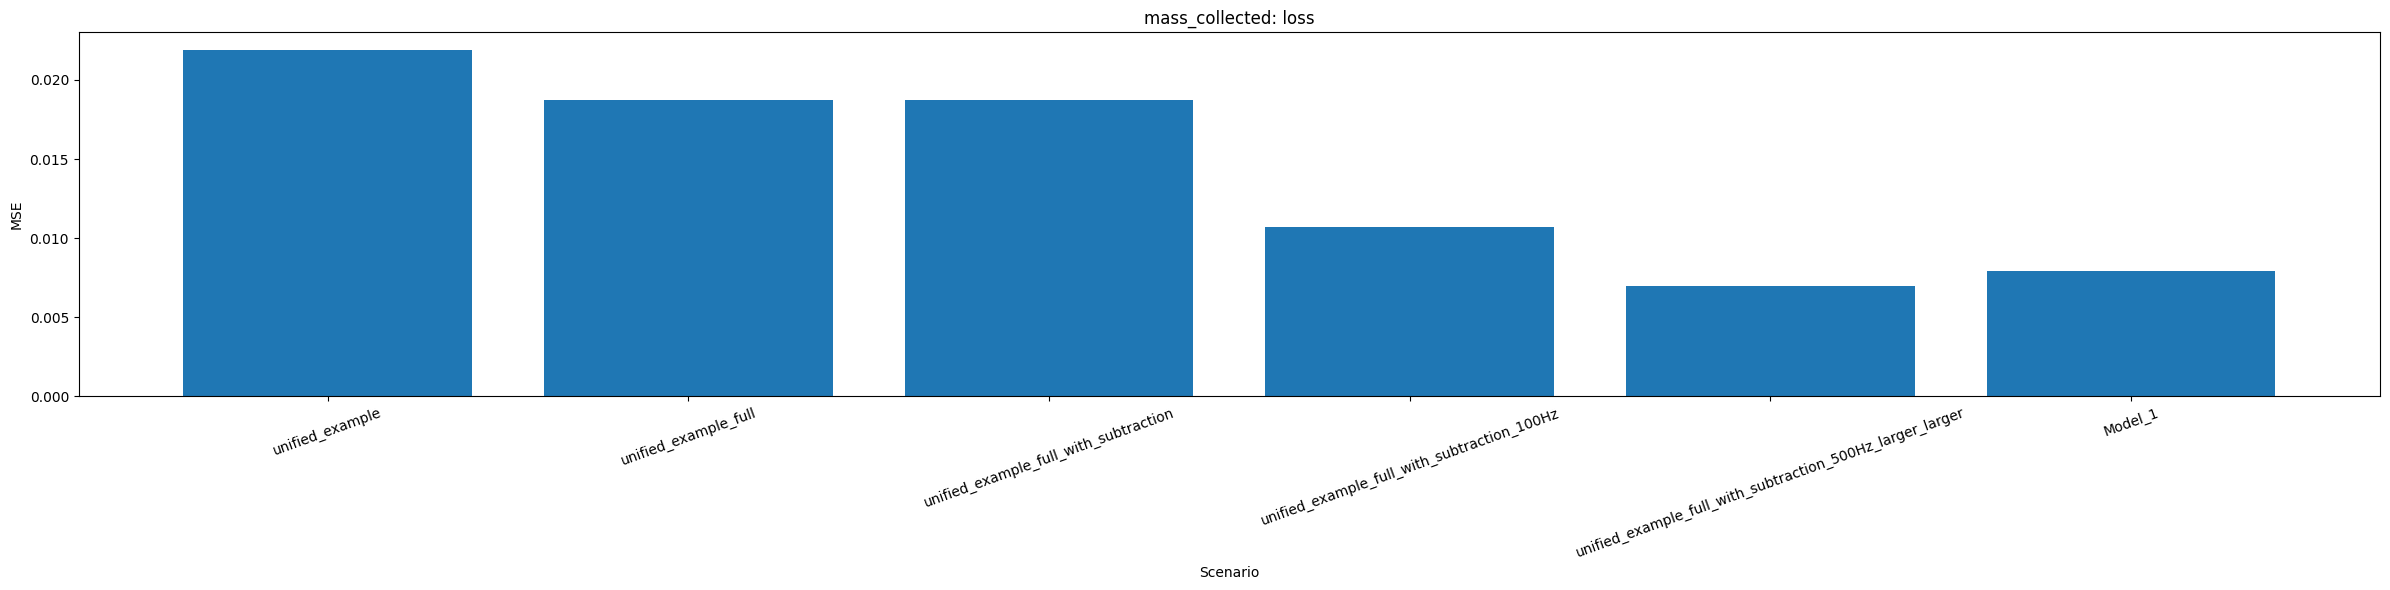

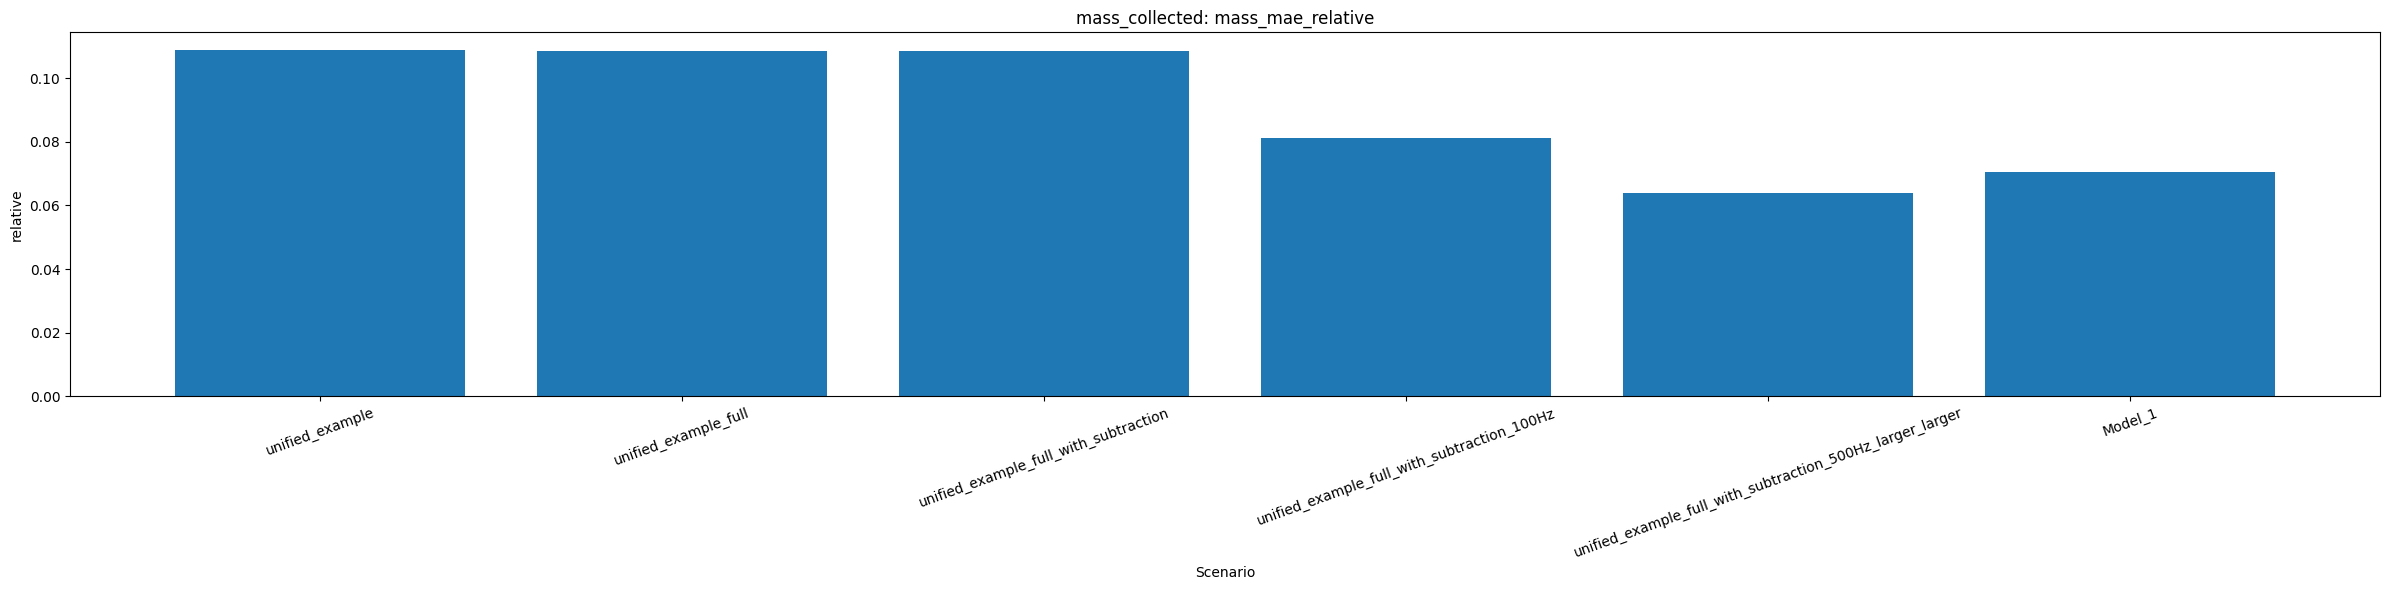

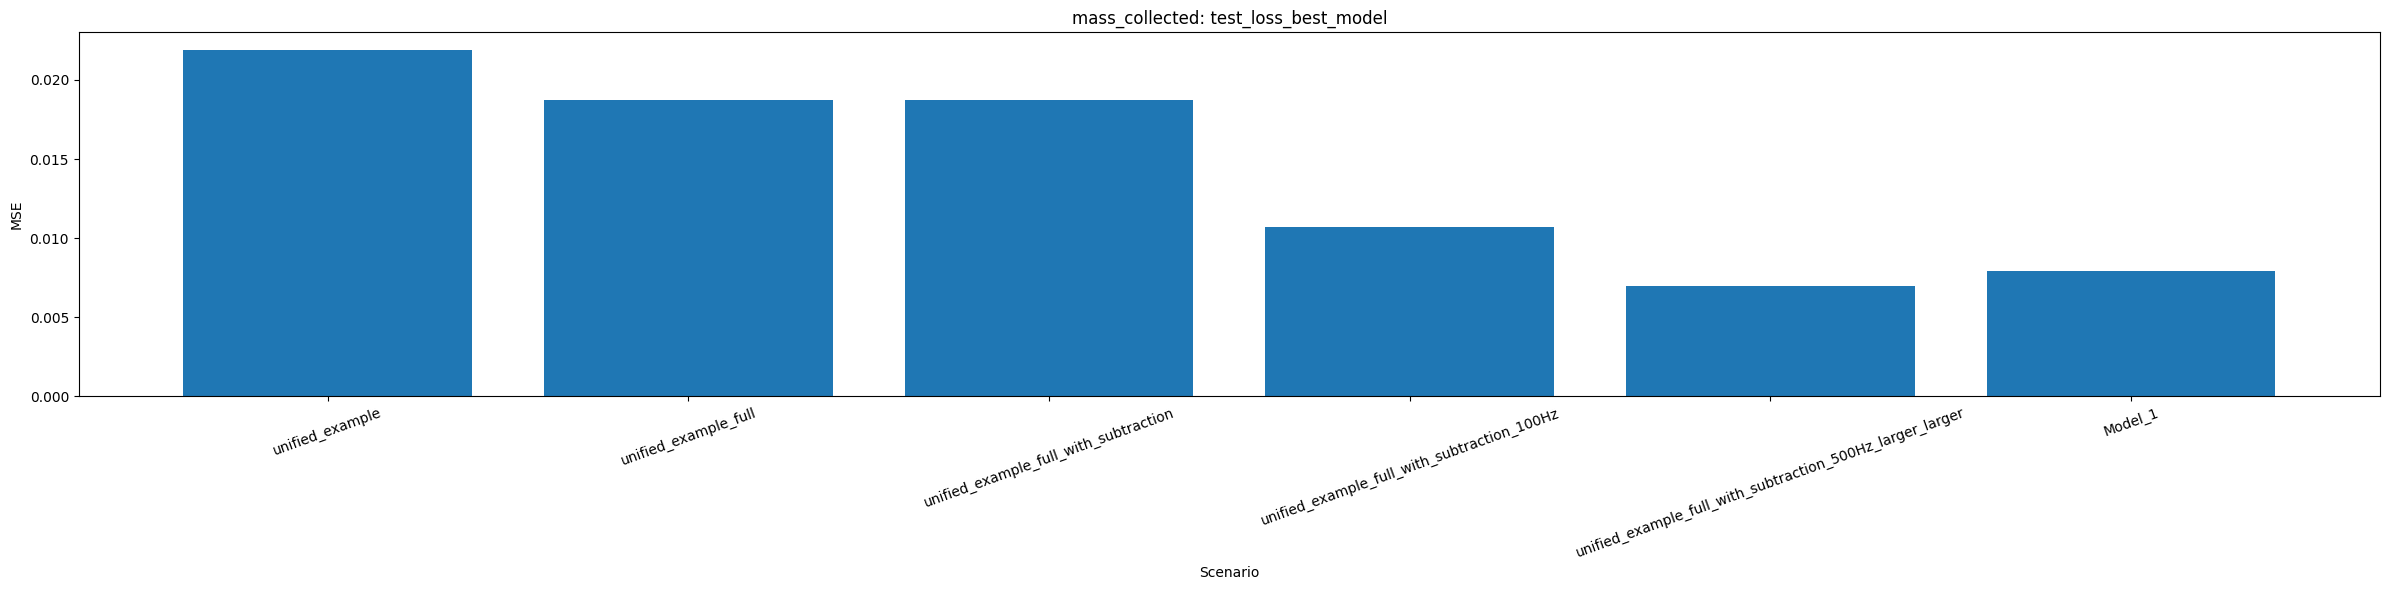

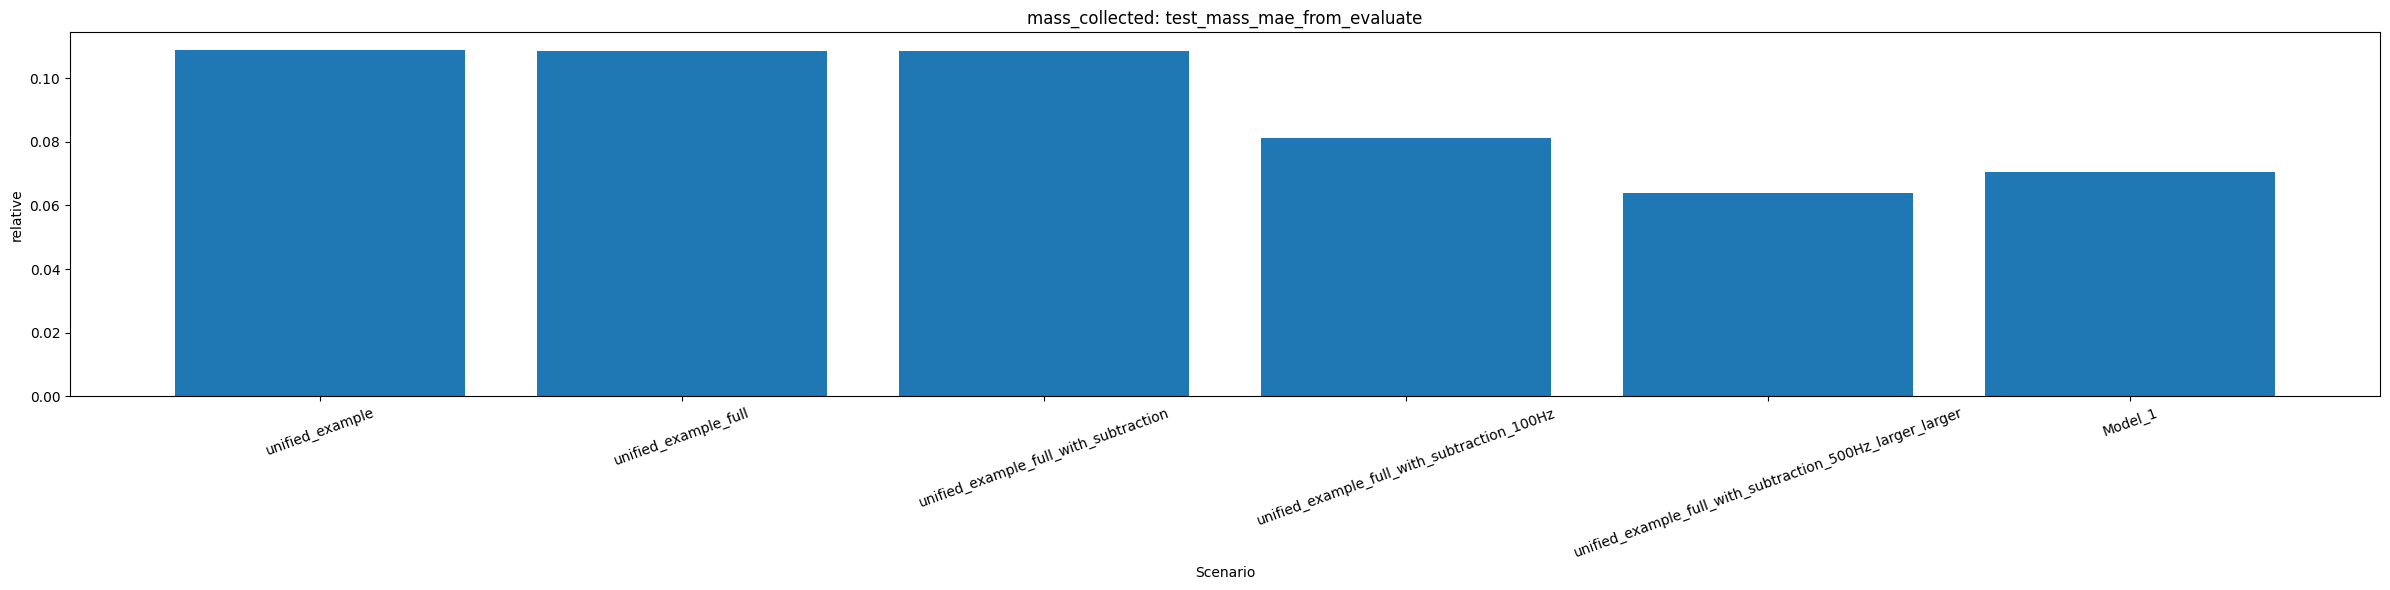

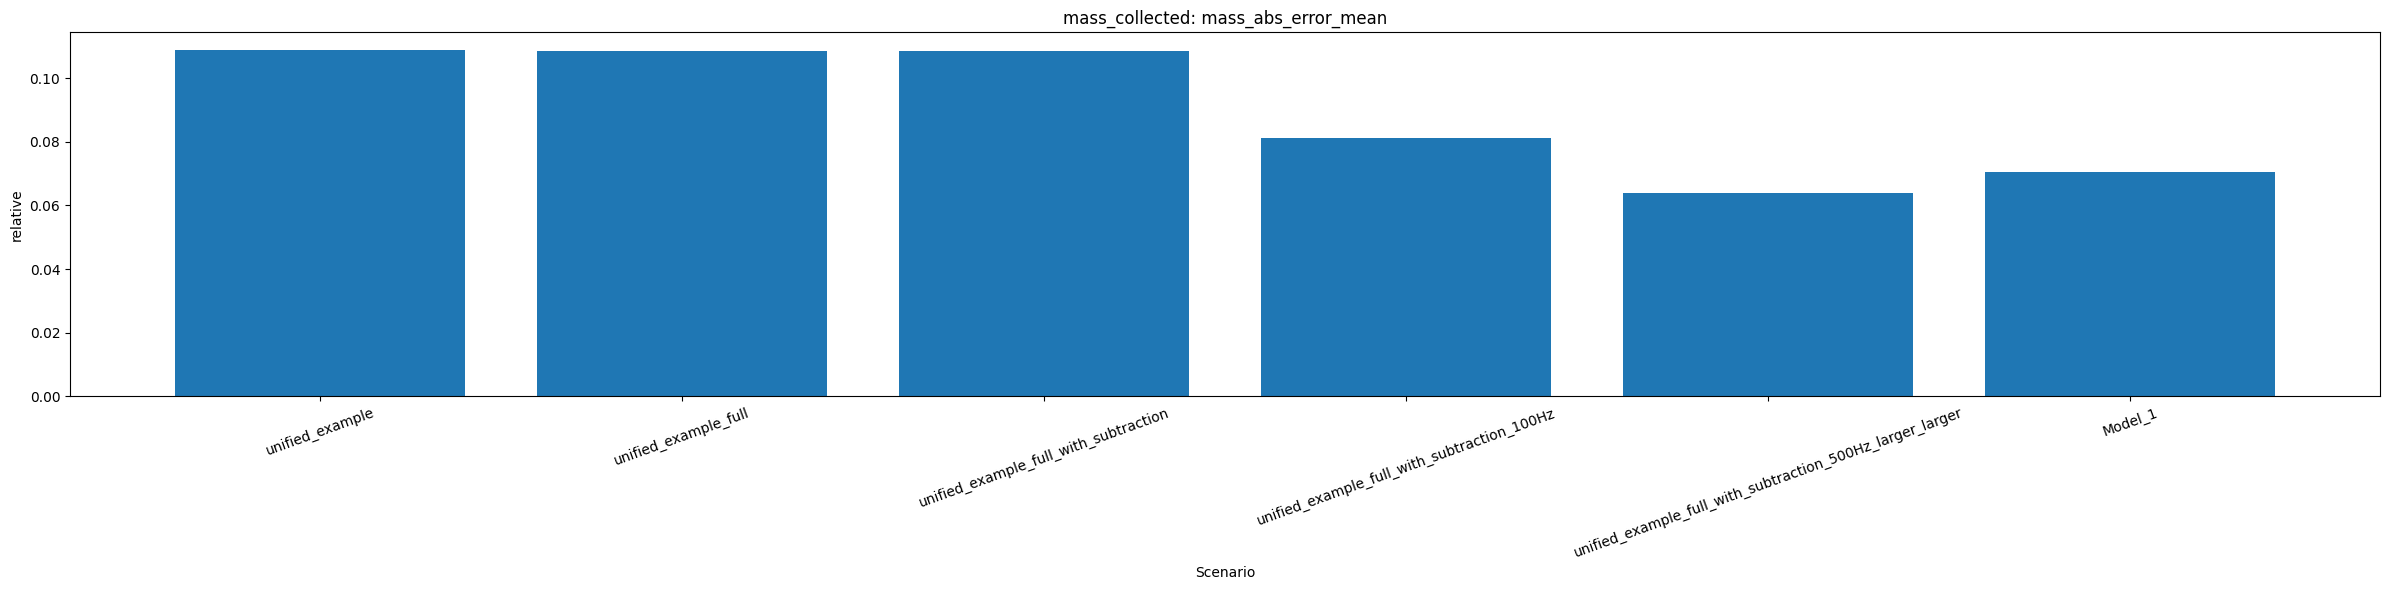

Saved: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\comparison_reports\mass_collected_history_comparison.csv


In [47]:
mass_collected_history_comparison, mass_collected_metrics_comparison = display_model_comparison("mass_collected")

## Compare `mass_public`

## mass_public

,model_name,scope,datasets
0,mass_public,mass,[public]


### Training history plots

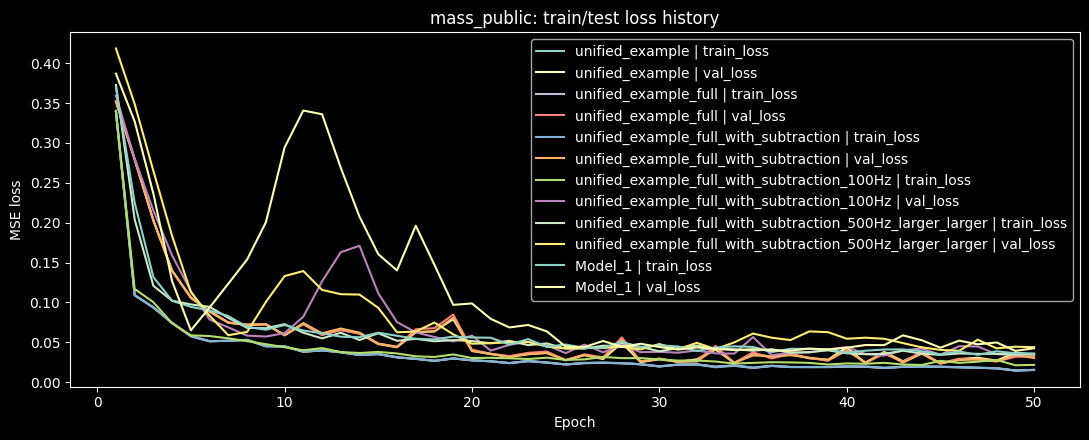

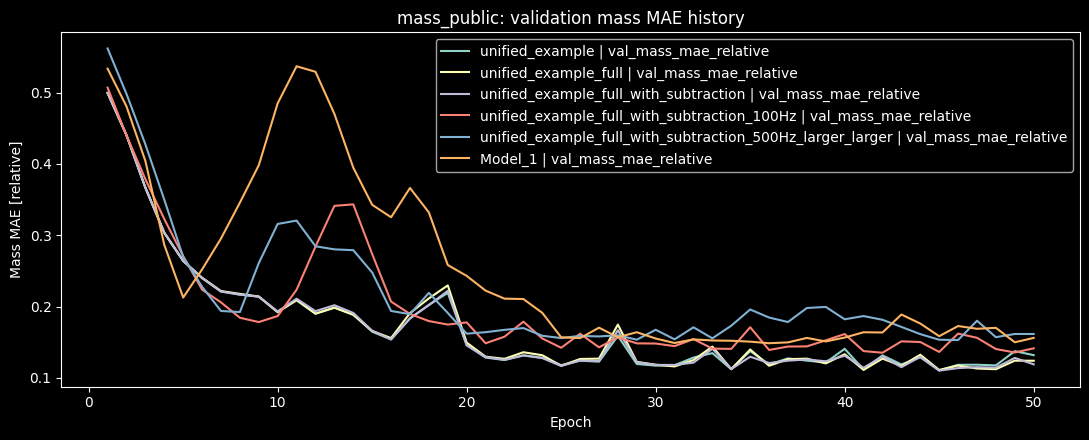

### Main metrics table

,scenario_name,model_name,metric,value,source,unit
60,Model_1,mass_public,loss,0.039179,metrics_json_final,MSE
0,unified_example,mass_public,loss,0.023376,metrics_json_final,MSE
12,unified_example_full,mass_public,loss,0.023401,metrics_json_final,MSE
24,unified_example_full_with_subtraction,mass_public,loss,0.023483,metrics_json_final,MSE
36,unified_example_full_with_subtraction_100Hz,mass_public,loss,0.033365,metrics_json_final,MSE
48,unified_example_full_with_subtraction_500Hz_la...,mass_public,loss,0.039381,metrics_json_final,MSE
64,Model_1,mass_public,mass_abs_error_mean,0.149846,final_grade_csv,relative
4,unified_example,mass_public,mass_abs_error_mean,0.110487,final_grade_csv,relative
16,unified_example_full,mass_public,mass_abs_error_mean,0.111028,final_grade_csv,relative
28,unified_example_full_with_subtraction,mass_public,mass_abs_error_mean,0.110142,final_grade_csv,relative


Saved: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\comparison_reports\mass_public_main_metrics_comparison.csv


### Main metrics bar plots

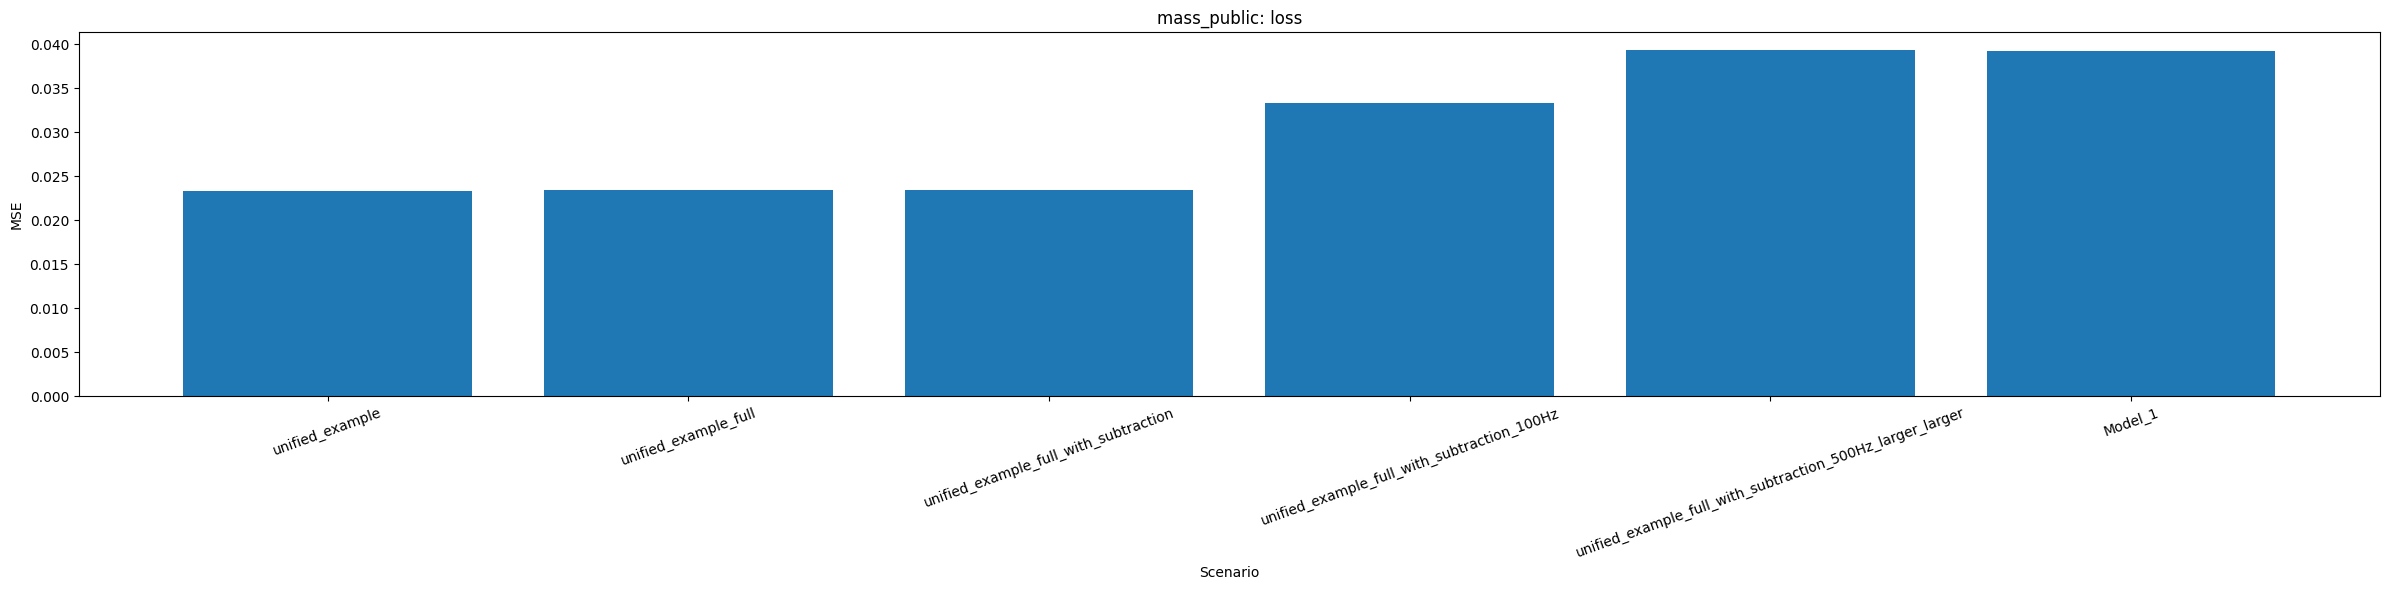

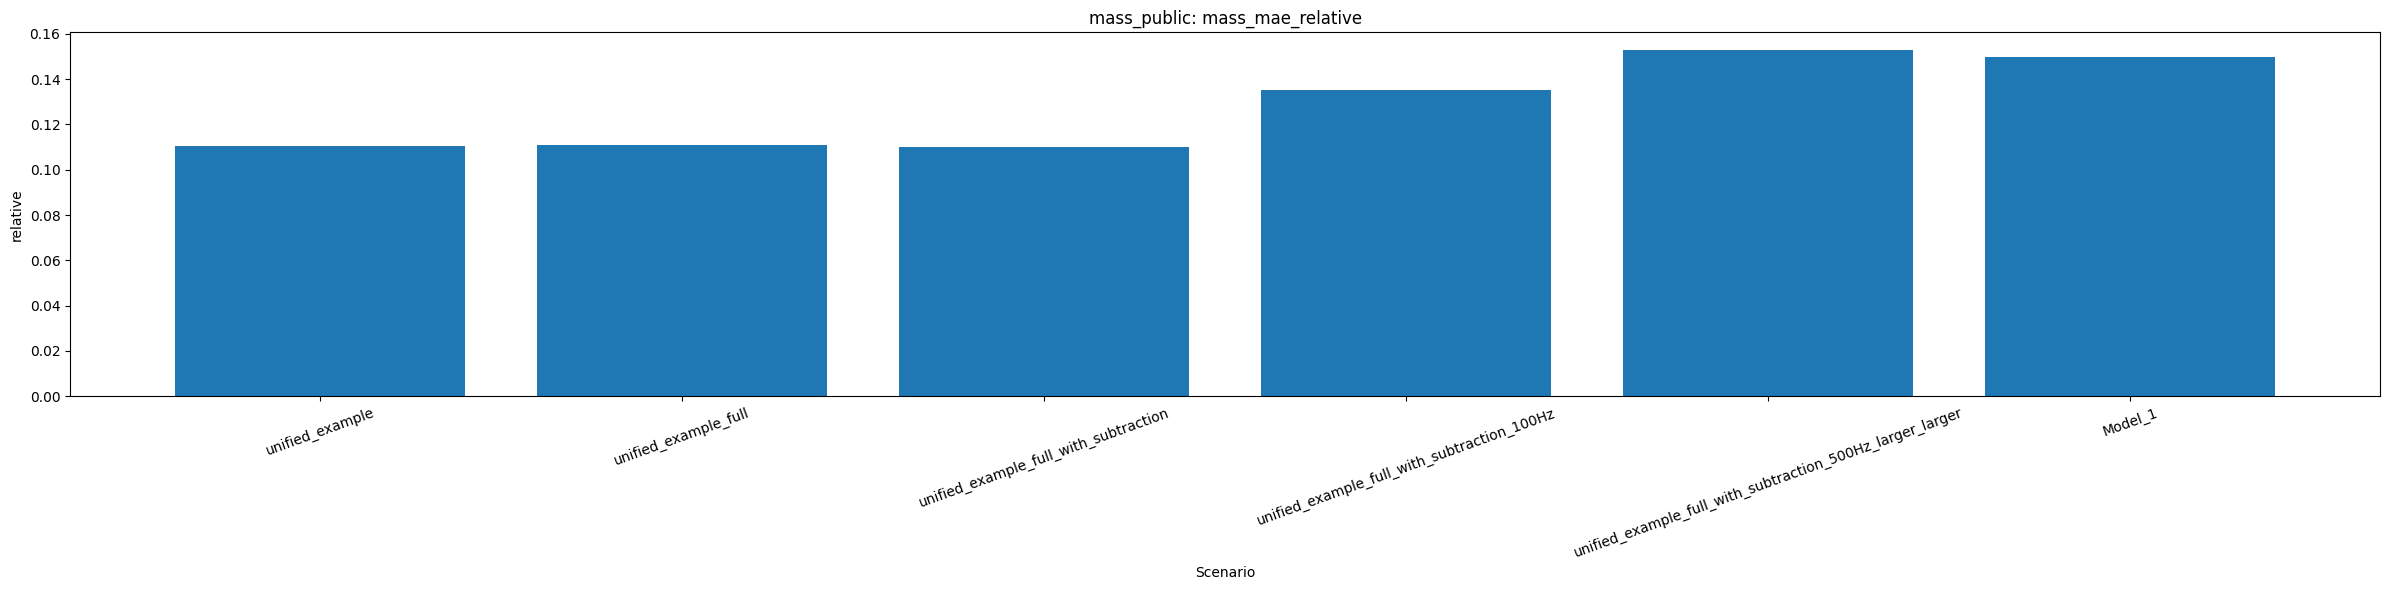

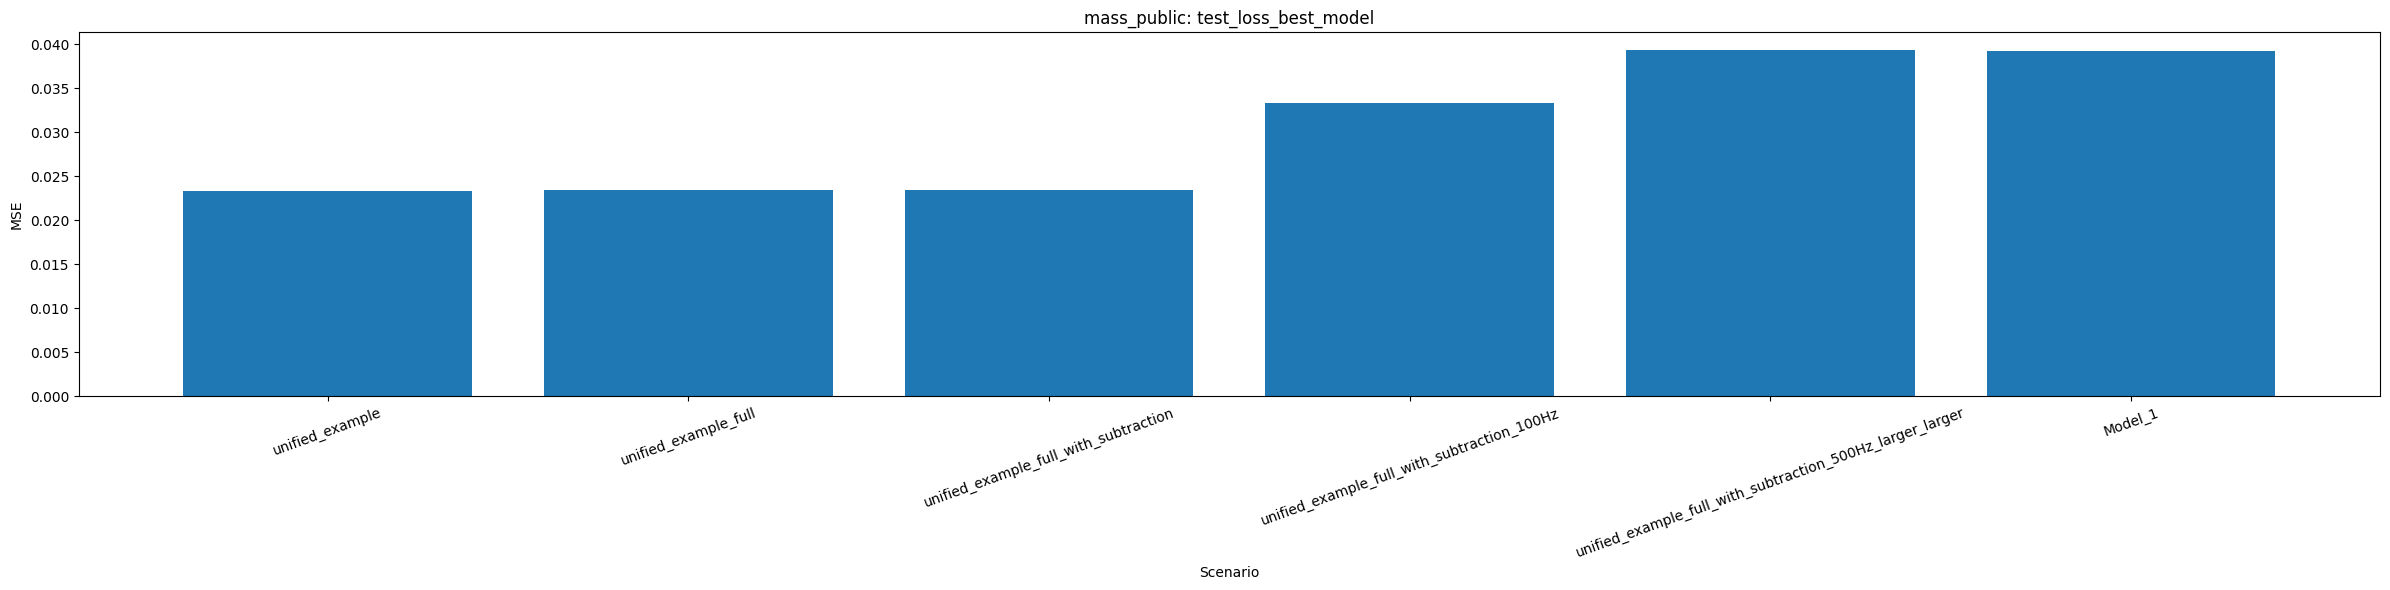

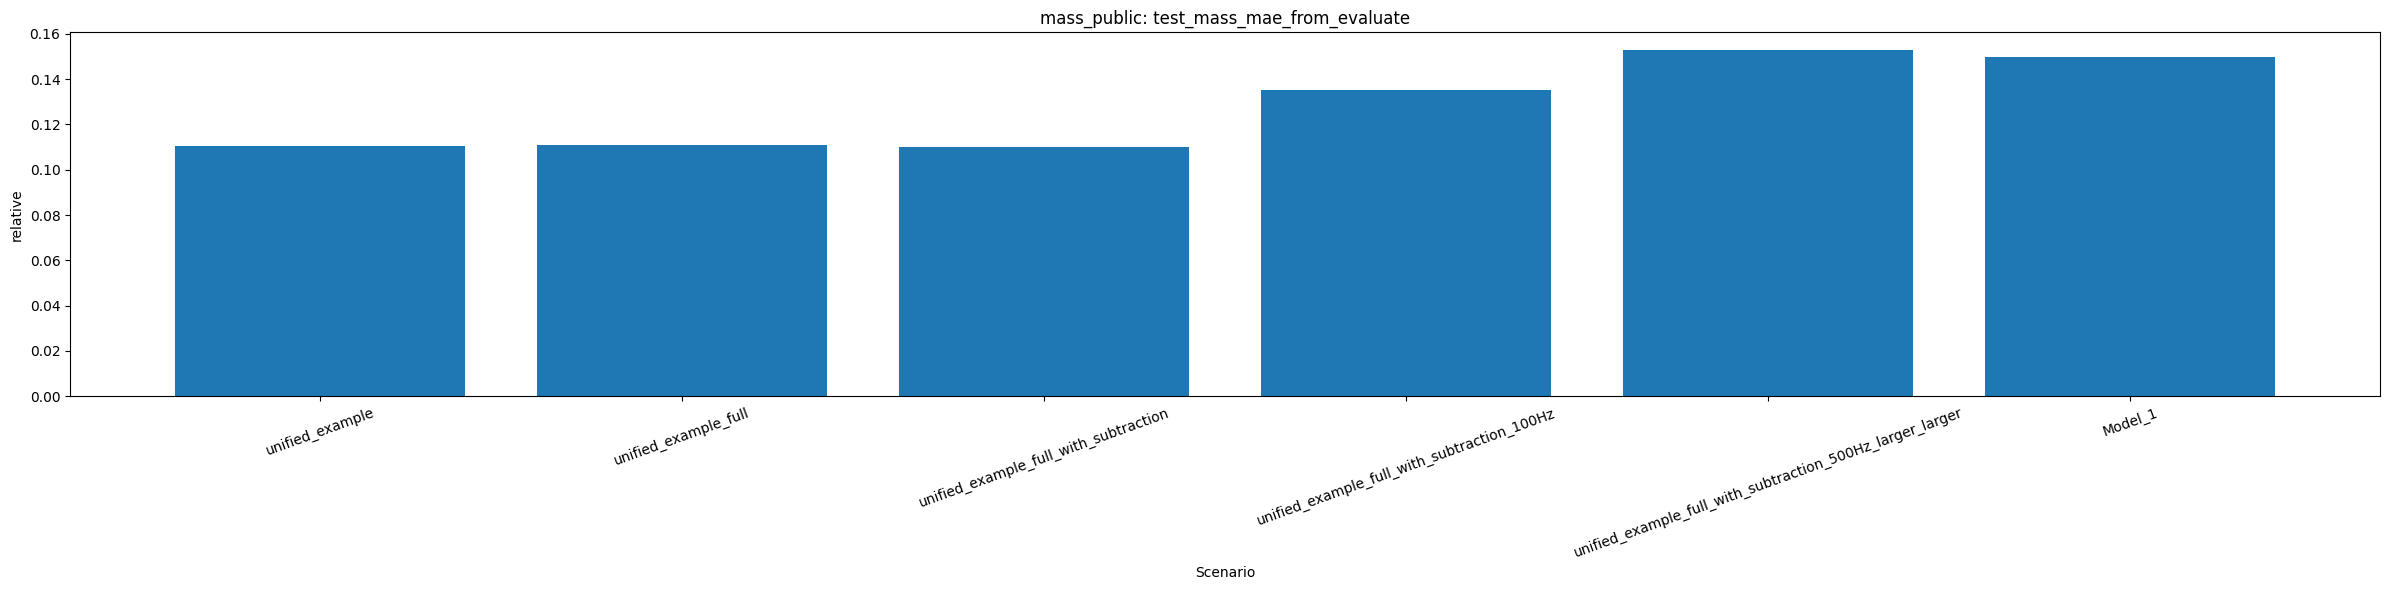

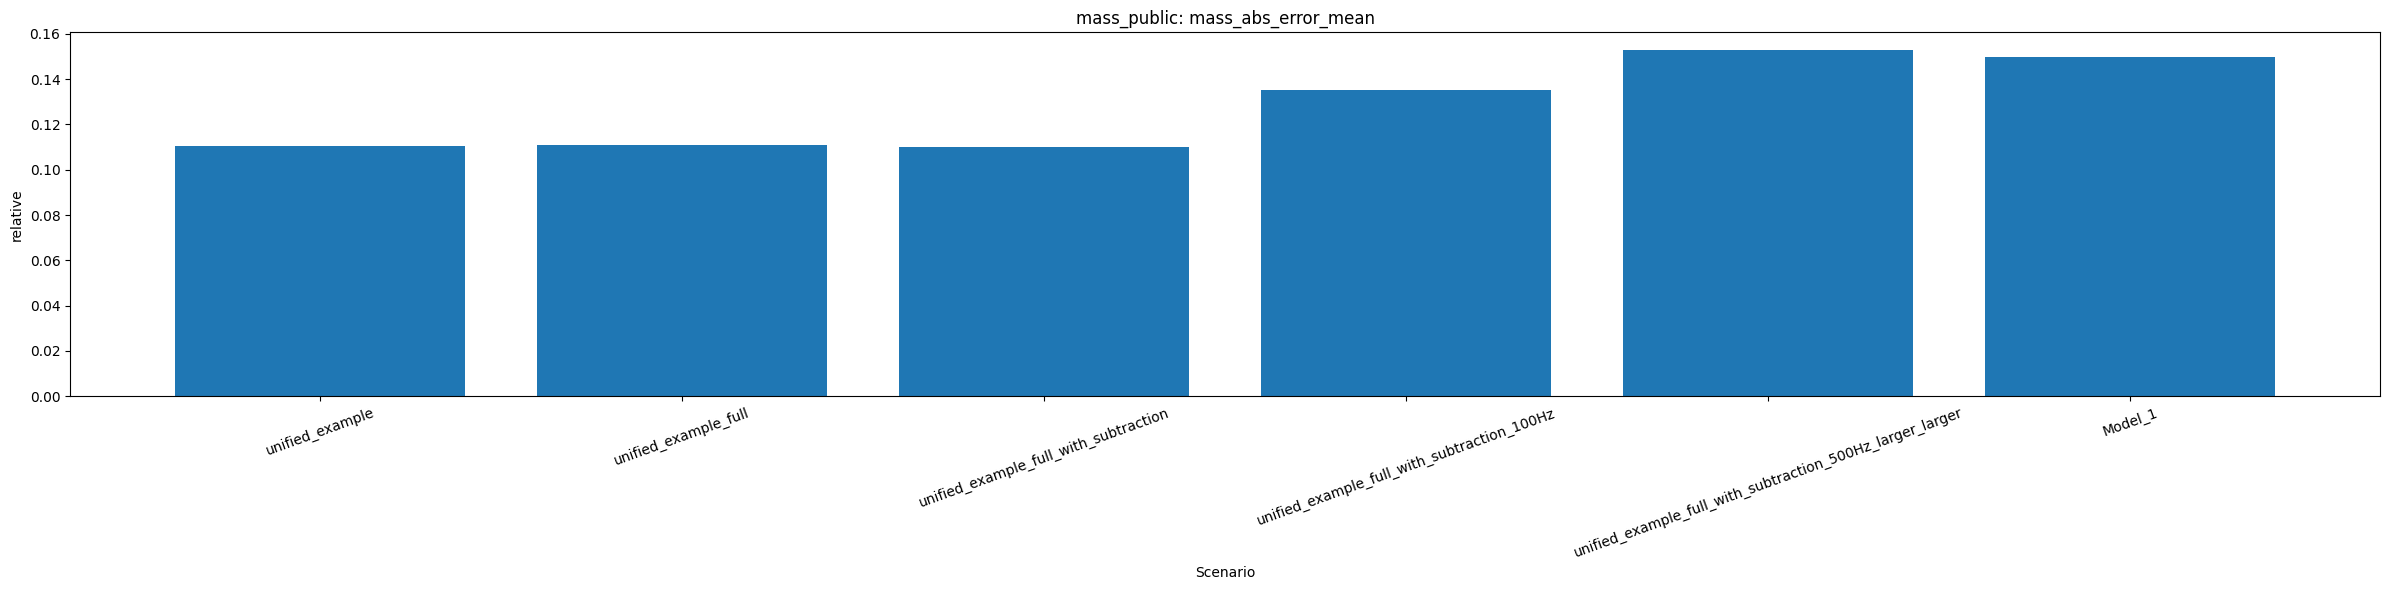

Saved: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\comparison_reports\mass_public_history_comparison.csv


In [48]:
mass_public_history_comparison, mass_public_metrics_comparison = display_model_comparison("mass_public")

## Compare `angle_mass_collected`

## angle_mass_collected

,model_name,scope,datasets
0,angle_mass_collected,both,[collected]


### Training history plots

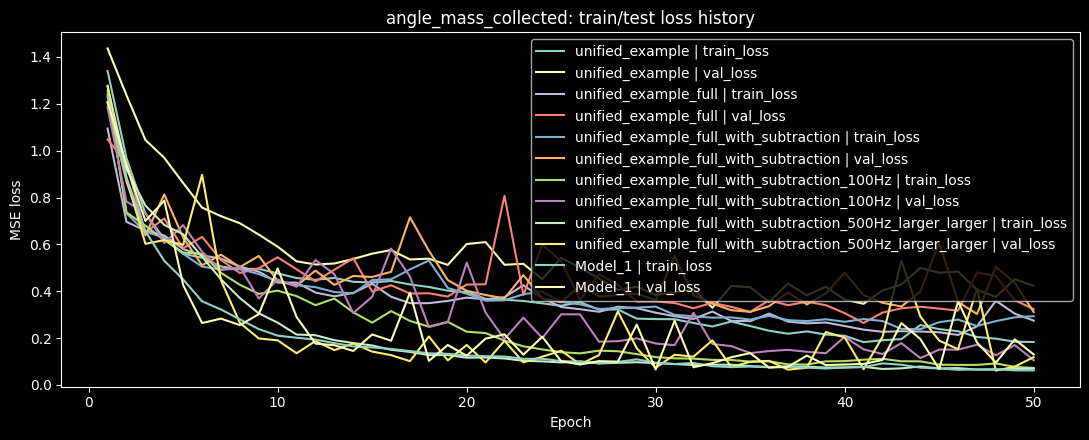

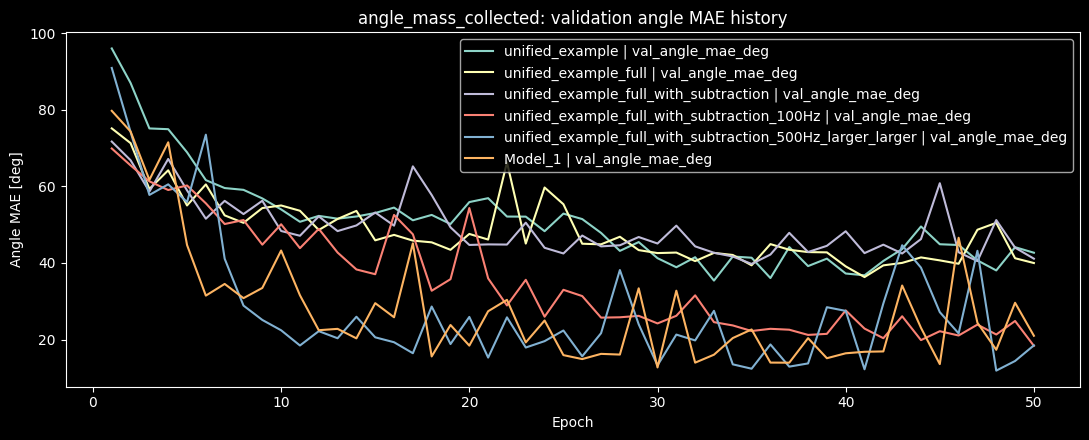

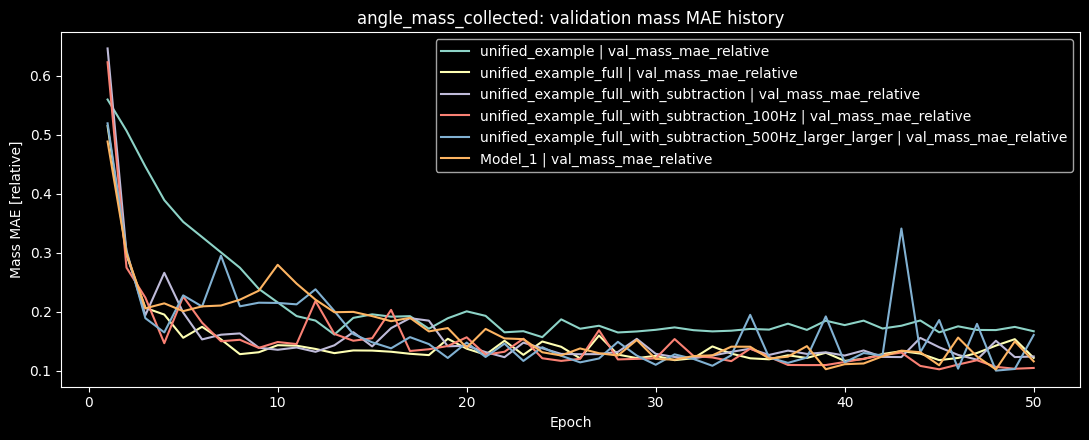

### Main metrics table

,scenario_name,model_name,metric,value,source,unit
95,Model_1,angle_mass_collected,angle_abs_error_mean,12.697444,final_grade_csv,deg
6,unified_example,angle_mass_collected,angle_abs_error_mean,35.396039,final_grade_csv,deg
24,unified_example_full,angle_mass_collected,angle_abs_error_mean,36.315337,final_grade_csv,deg
42,unified_example_full_with_subtraction,angle_mass_collected,angle_abs_error_mean,40.487371,final_grade_csv,deg
60,unified_example_full_with_subtraction_100Hz,angle_mass_collected,angle_abs_error_mean,18.343440,final_grade_csv,deg
78,unified_example_full_with_subtraction_500Hz_la...,angle_mass_collected,angle_abs_error_mean,11.874593,final_grade_csv,deg
91,Model_1,angle_mass_collected,angle_mae_deg,12.697443,metrics_json_final,deg
1,unified_example,angle_mass_collected,angle_mae_deg,35.396042,metrics_json_final,deg
19,unified_example_full,angle_mass_collected,angle_mae_deg,36.315334,metrics_json_final,deg
37,unified_example_full_with_subtraction,angle_mass_collected,angle_mae_deg,40.487366,metrics_json_final,deg


Saved: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\comparison_reports\angle_mass_collected_main_metrics_comparison.csv


### Main metrics bar plots

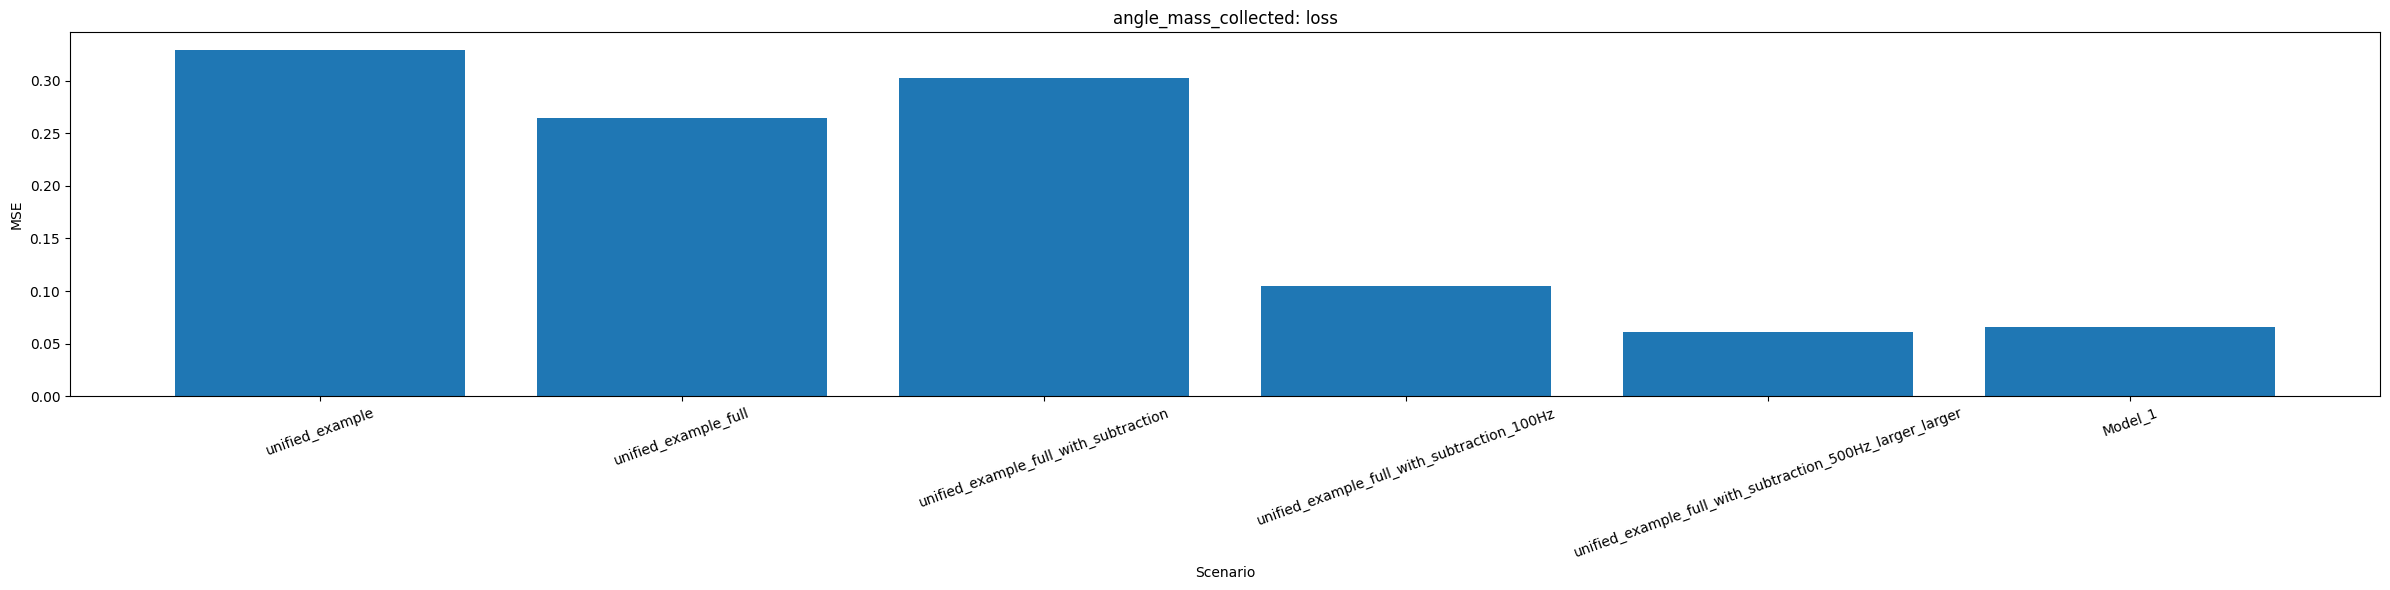

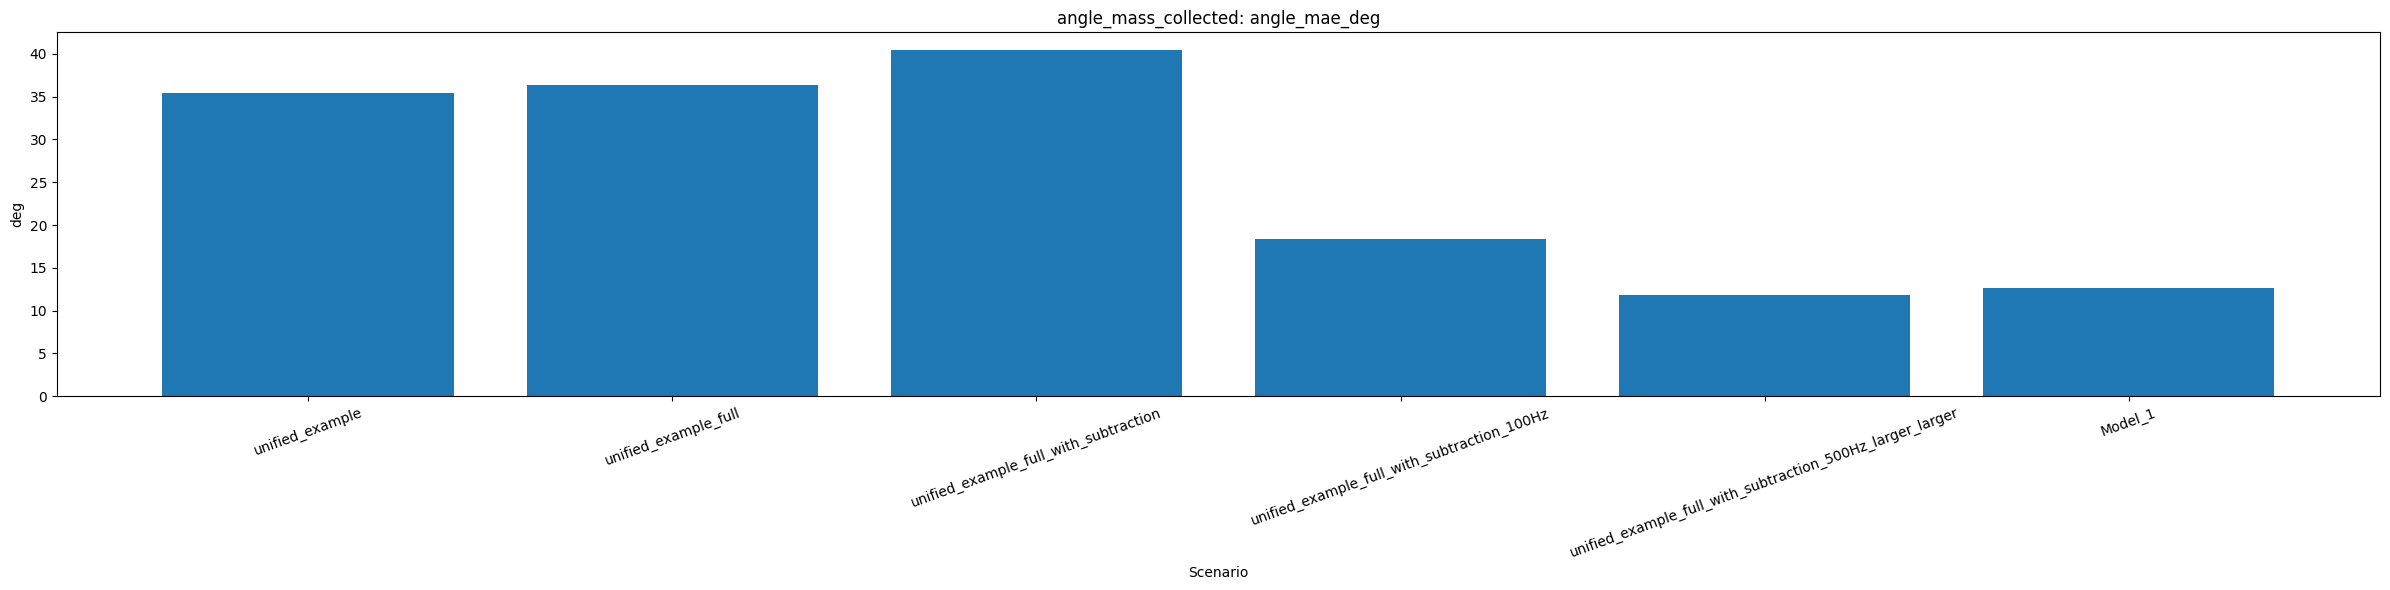

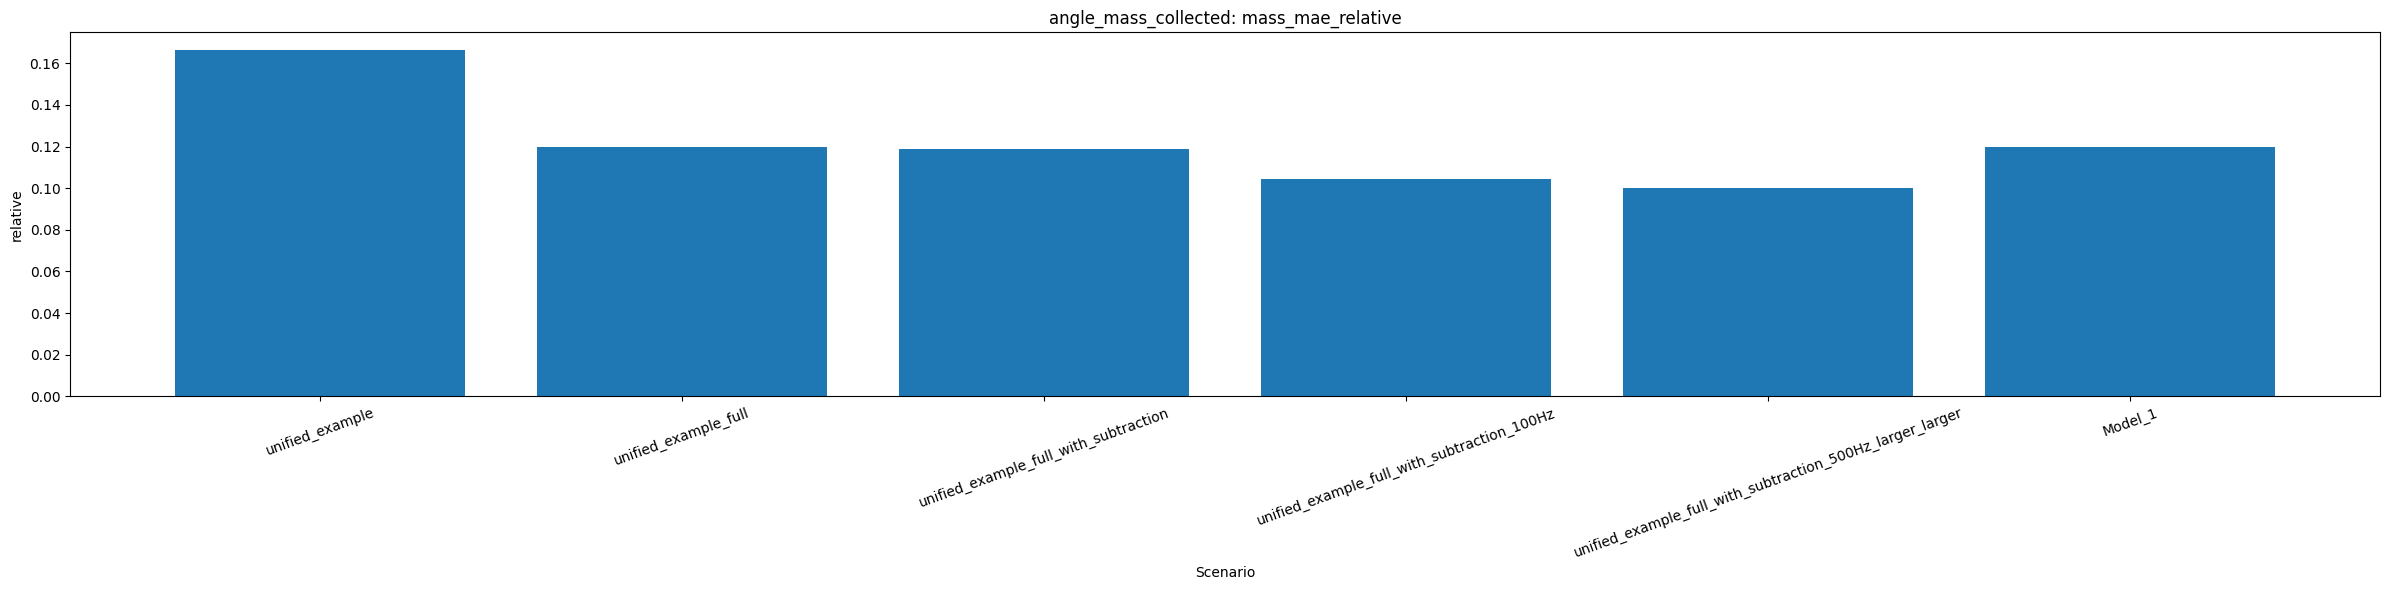

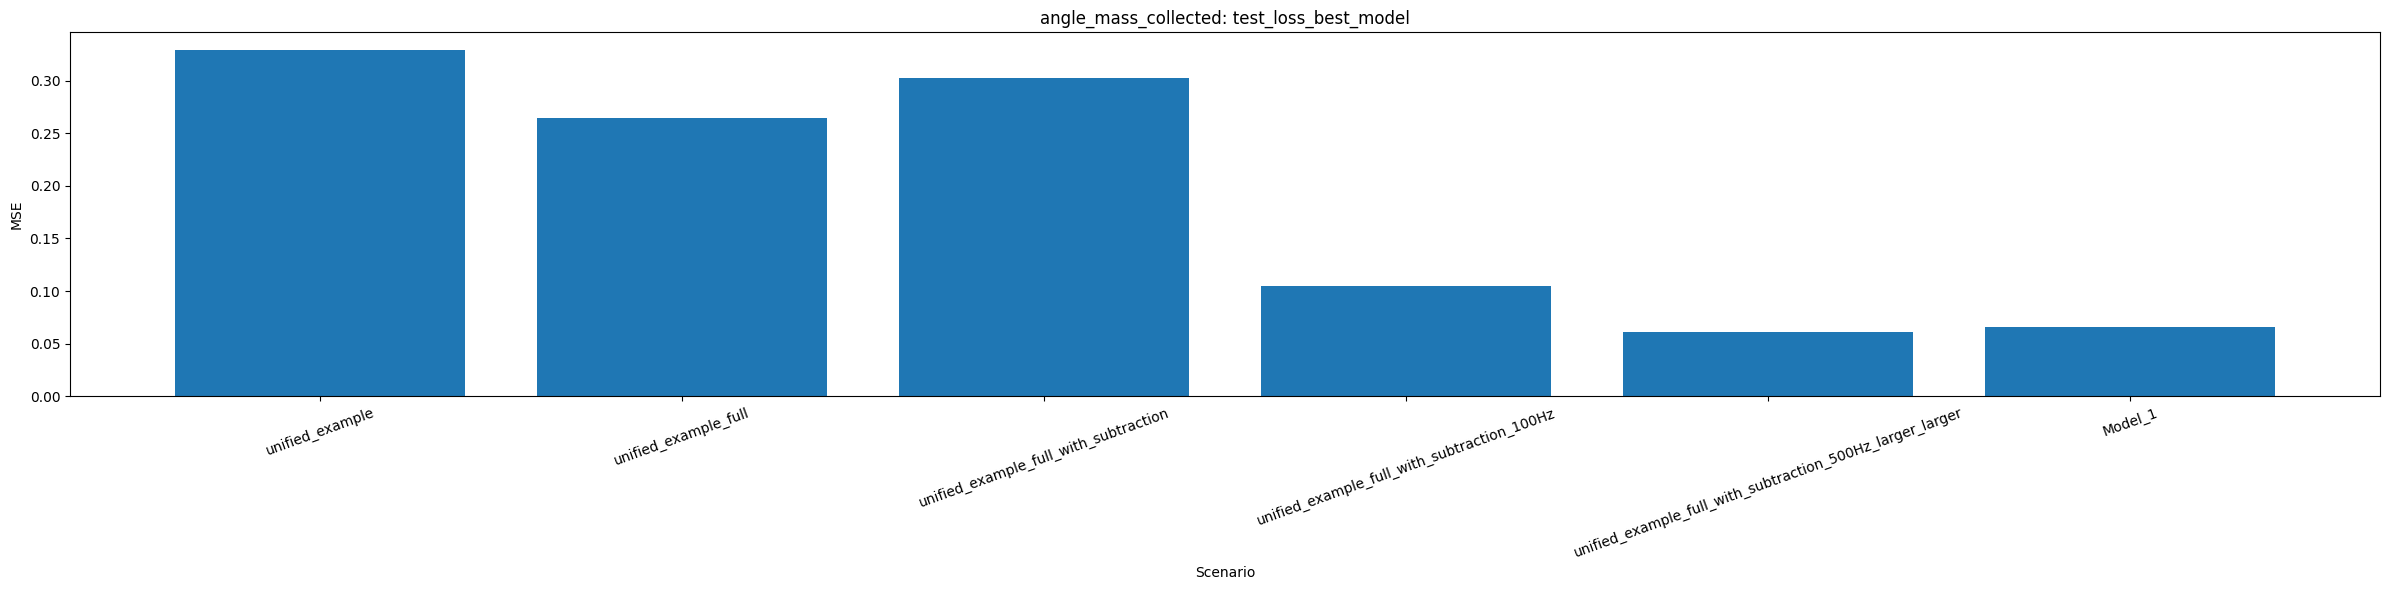

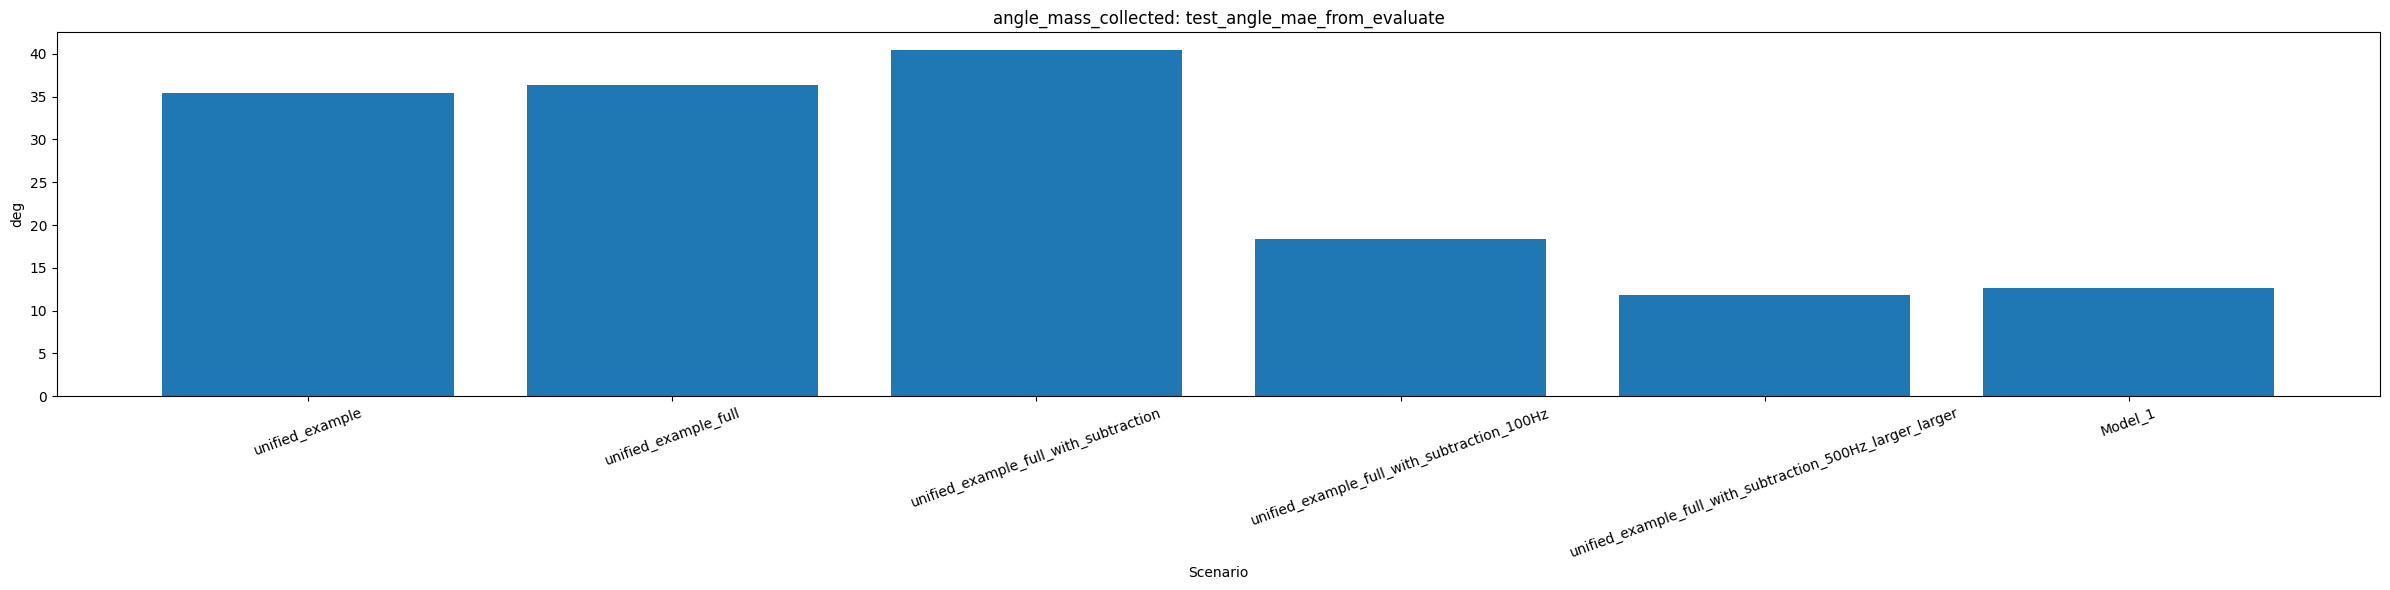

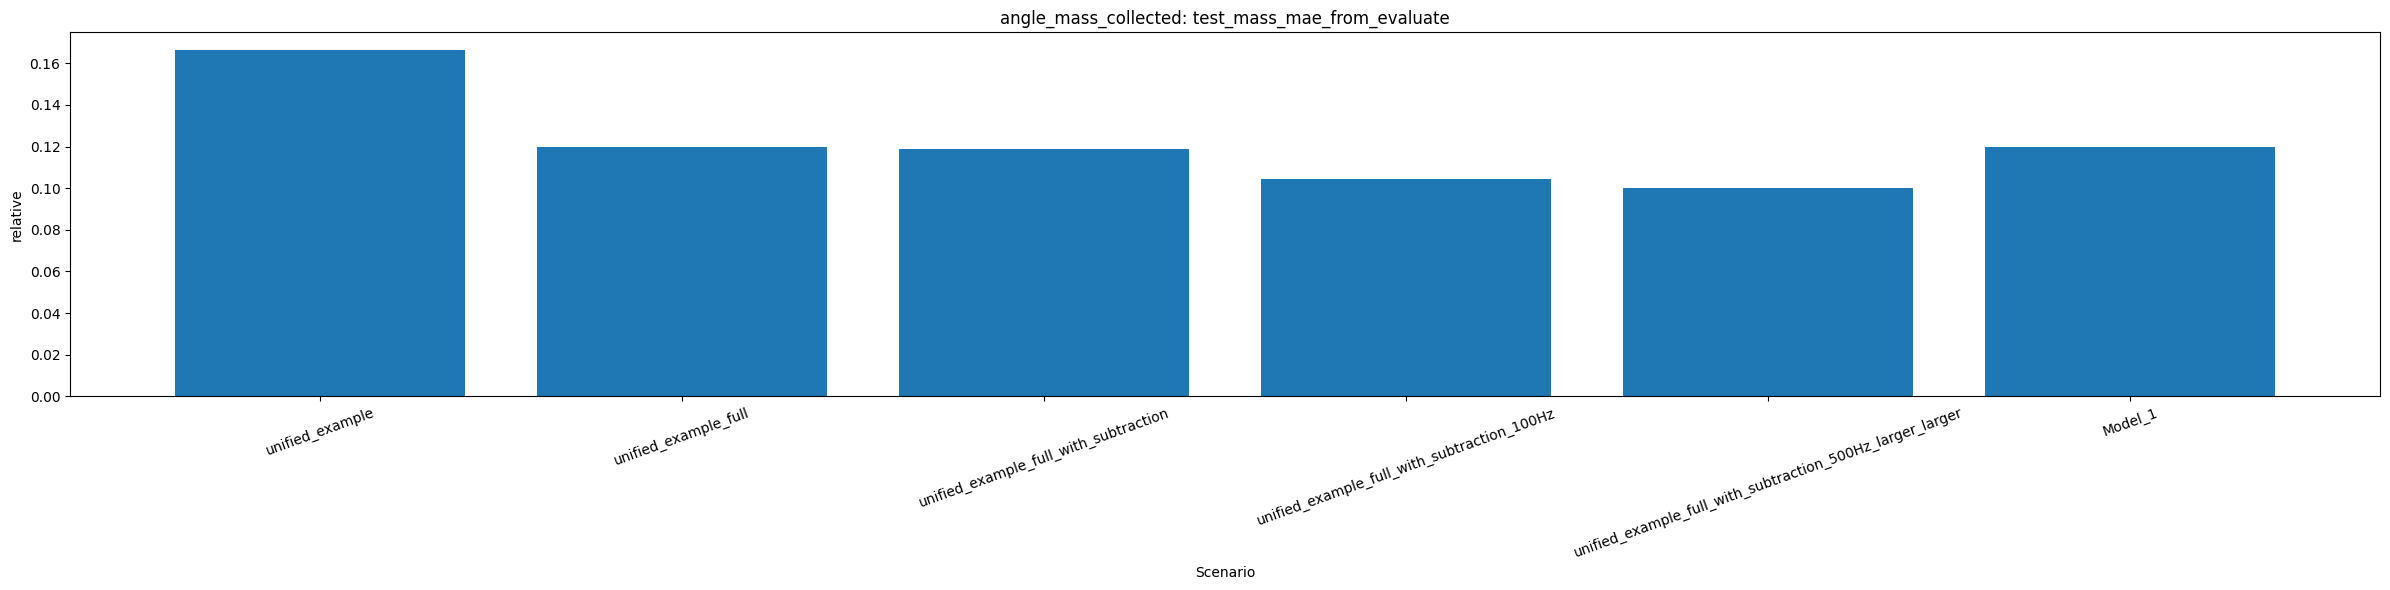

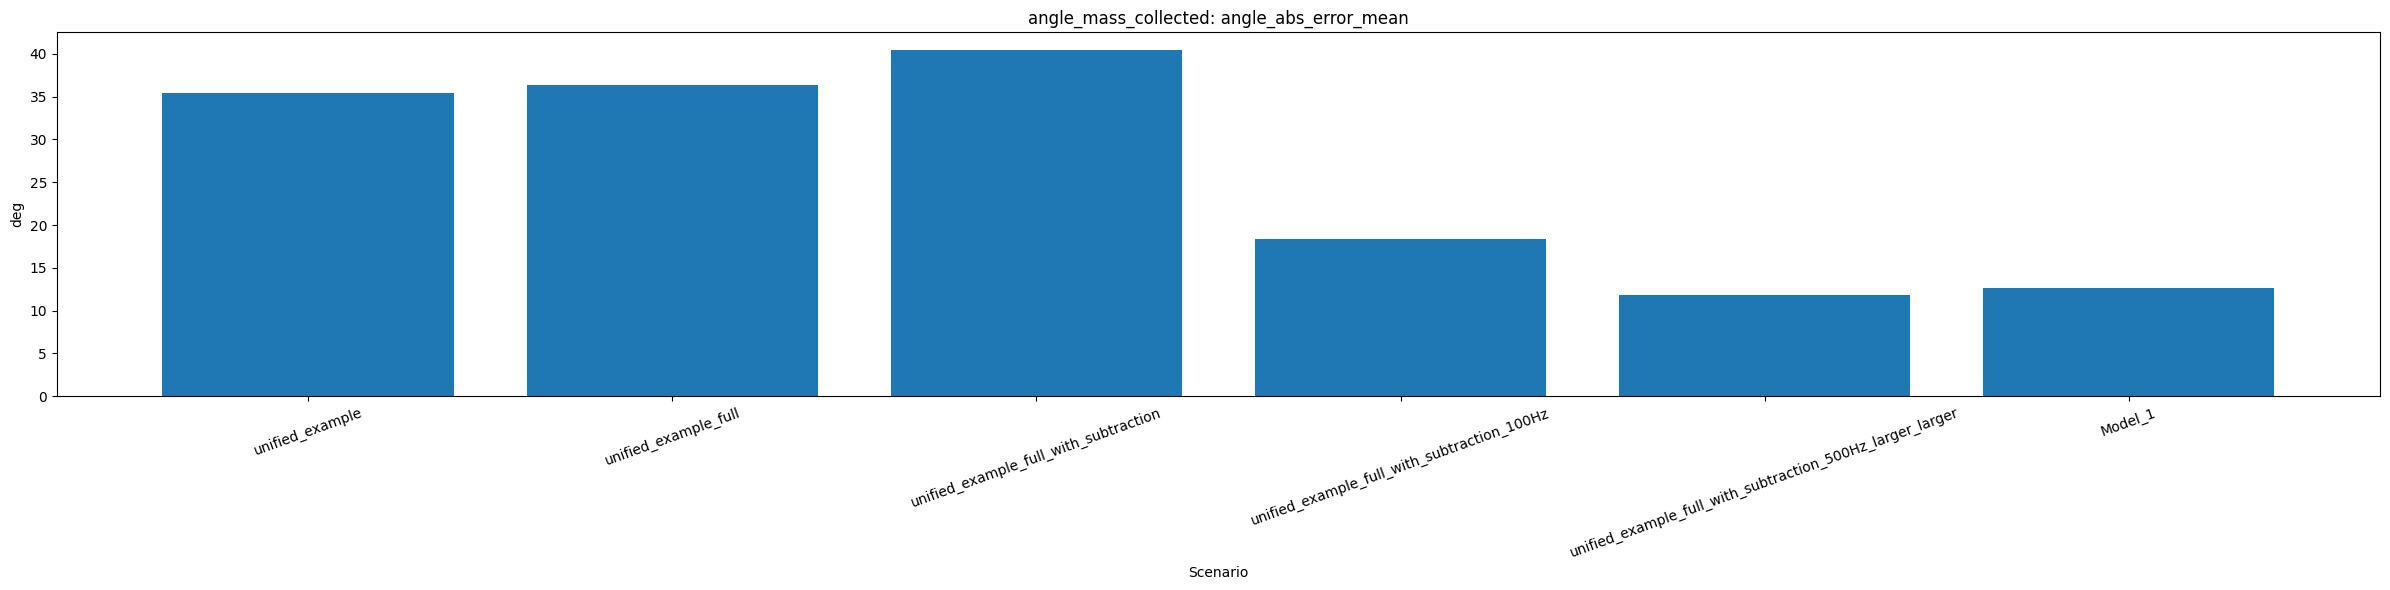

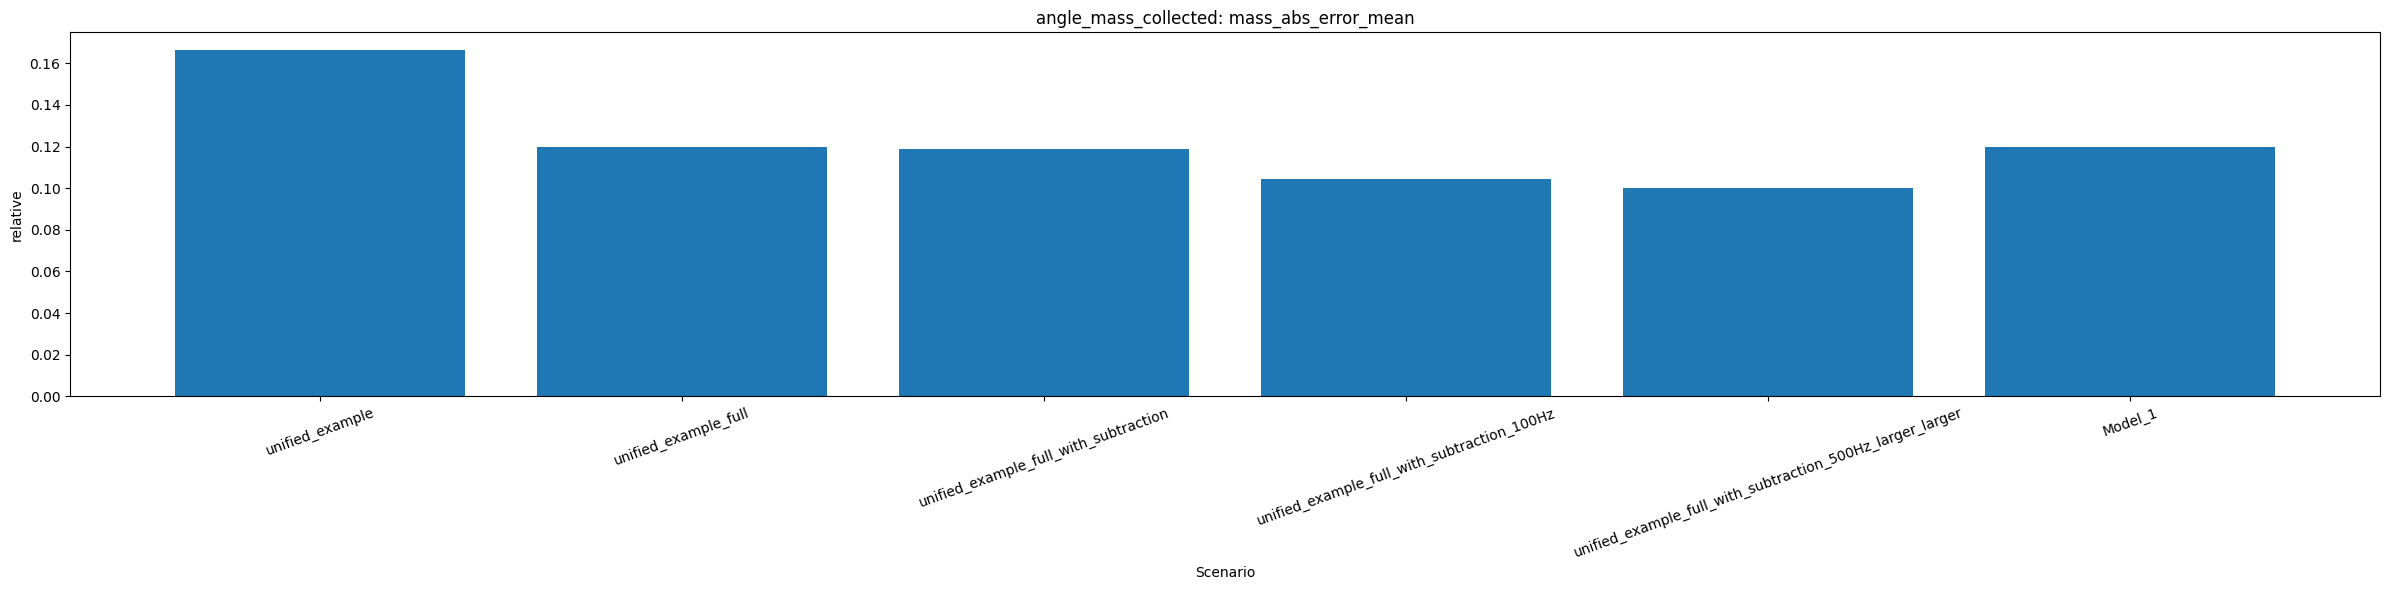

Saved: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\comparison_reports\angle_mass_collected_history_comparison.csv


In [49]:
angle_mass_collected_history_comparison, angle_mass_collected_metrics_comparison = display_model_comparison("angle_mass_collected")

## Combined main metrics table

In [50]:
all_metrics = []
for model_name in MODEL_NAMES:
    _, metrics_df, _ = load_model_bundle(model_name)
    if len(metrics_df):
        df = main_metrics_for_bars(metrics_df, model_name)
        if len(df):
            all_metrics.append(df)

all_model_main_metrics = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
display(all_model_main_metrics)

summary_path = OUTPUT_DIR / "all_model_main_metrics_comparison.csv"
all_model_main_metrics.to_csv(summary_path, index=False)
print("Saved:", summary_path)

,scenario_name,model_name,metric,value,source,unit
0,unified_example,angle_collected,loss,0.269379,metrics_json_final,MSE
1,unified_example_full,angle_collected,loss,0.289707,metrics_json_final,MSE
2,unified_example_full_with_subtraction,angle_collected,loss,0.272502,metrics_json_final,MSE
3,unified_example_full_with_subtraction_100Hz,angle_collected,loss,0.097862,metrics_json_final,MSE
4,unified_example_full_with_subtraction_500Hz_la...,angle_collected,loss,0.050191,metrics_json_final,MSE
...,...,...,...,...,...,...
133,unified_example_full,angle_mass_collected,mass_abs_error_mean,0.119777,final_grade_csv,relative
134,unified_example_full_with_subtraction,angle_mass_collected,mass_abs_error_mean,0.118587,final_grade_csv,relative
135,unified_example_full_with_subtraction_100Hz,angle_mass_collected,mass_abs_error_mean,0.104535,final_grade_csv,relative
136,unified_example_full_with_subtraction_500Hz_la...,angle_mass_collected,mass_abs_error_mean,0.100029,final_grade_csv,relative


Saved: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\comparison_reports\all_model_main_metrics_comparison.csv
